In [1]:
# ===== Step 1A: Install & pin packages (Kaggle) =====
# NOTE: This pins versions known to work with TF 2.15 and scikit-learn 1.3.x.
# Run this cell (may show some dependency warnings — that's ok). If TensorFlow import later shows wrong version, restart the kernel and re-run imports.
!pip -q install numpy==1.26.4 scipy==1.11.4 scikit-learn==1.3.2 tensorflow==2.15.0 \
    opencv-python-headless==4.10.0.84 albumentations==1.3.0 matplotlib==3.8.0 \
    pandas==2.2.3 pillow seaborn==0.13.2 tqdm scikit-image imbalanced-learn==0.11.0 \
    pydicom imageio

print("Install step finished. If TensorFlow version does not match in the verification cell, restart the notebook kernel and re-run the import cell.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 51.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 99.3 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.3/475.3 MB 3.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 39.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.5/123.5 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 105.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.6/235.6 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 105.6 MB/s eta 0:00:

In [2]:
# ===== Step 1B: Import & verify environment =====
import os, random, sys
import numpy as np
import pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
import cv2
import tensorflow as tf
import sklearn
import albumentations as A
import pydicom
from sklearn import __version__ as sklearn_version
from tensorflow.keras import backend as K

# Reduce TF log spam
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Reproducibility seeds
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Print versions & device info
print("Python:", sys.version.splitlines()[0])
print("NumPy:", np.__version__)
print("SciPy:", __import__("scipy").__version__)
print("scikit-learn:", sklearn_version)
print("TensorFlow:", tf.__version__)
print("OpenCV:", cv2.__version__)
print("Albumentations:", A.__version__)
print("pydicom:", pydicom.__version__)
print("matplotlib:", mpl.__version__)
print("pandas:", pd.__version__)

# GPU check
gpus = tf.config.list_physical_devices('GPU')
print("GPUs detected:", len(gpus))
if gpus:
    for g in gpus:
        print(" -", g)

# quick tensorflow sanity (simple op)
try:
    arr = tf.constant(np.arange(6).reshape(2,3), dtype=tf.int32)
    print("TF quick op ok. shape:", arr.shape)
except Exception as e:
    print("TensorFlow quick op failed:", e)

# Small helper: show where to look for dataset (Kaggle)
kaggle_input = "/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset"
print("Kaggle input mount exists:", os.path.exists(kaggle_input), "->", kaggle_input)

print("\nIf any import fails or versions are unexpected, copy & paste the full error here and I'll help fix it.")


2026-04-18 15:32:50.551539: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-18 15:32:50.551607: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-18 15:32:50.553069: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
NumPy: 1.26.4
SciPy: 1.11.4
scikit-learn: 1.3.2
TensorFlow: 2.15.0
OpenCV: 4.10.0
Albumentations: 1.3.0
pydicom: 3.0.1
matplotlib: 3.7.2
pandas: 2.2.3
GPUs detected: 0
TF quick op ok. shape: (2, 3)
Kaggle input mount exists: True -> /kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset

If any import fails or versions are unexpected, copy & paste the full error here and I'll help fix it.


Found CSVs:
 - csv/dicom_info.csv
 - csv/mass_case_description_train_set.csv
 - csv/calc_case_description_train_set.csv
 - csv/meta.csv
 - csv/calc_case_description_test_set.csv
 - csv/mass_case_description_test_set.csv
dicom_info.csv -> shape (10237, 38)
mass_case_description_train_set.csv -> shape (1318, 14)
calc_case_description_train_set.csv -> shape (1546, 14)
meta.csv -> shape (6775, 9)
calc_case_description_test_set.csv -> shape (326, 14)
mass_case_description_test_set.csv -> shape (378, 14)


,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....


,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00005,3,RIGHT,CC,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_CC/1.3.6.1.4.1.959...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...
1,P_00005,3,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_MLO/1.3.6.1.4.1.95...,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....
2,P_00007,4,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00007,4,LEFT,MLO,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_MLO/1.3.6.1.4.1.959...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00008,1,LEFT,CC,1,calcification,NaN,REGIONAL,2,BENIGN_WITHOUT_CALLBACK,3,Calc-Training_P_00008_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...



mass_case_description_train_set:
pathology
MALIGNANT                  637
BENIGN                     577
BENIGN_WITHOUT_CALLBACK    104
Name: count, dtype: int64

mass_case_description_test_set:
pathology
BENIGN                     194
MALIGNANT                  147
BENIGN_WITHOUT_CALLBACK     37
Name: count, dtype: int64

calc_case_description_train_set:
pathology
MALIGNANT                  544
BENIGN                     528
BENIGN_WITHOUT_CALLBACK    474
Name: count, dtype: int64

calc_case_description_test_set:
pathology
BENIGN                     130
MALIGNANT                  129
BENIGN_WITHOUT_CALLBACK     67
Name: count, dtype: int64

Total .jpg images found: 10237
Sample paths: ['/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.426013102412536473840491086280519425818/1-223.jpg', '/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.16568542011655175430071162144126831780/2-089.jpg', 

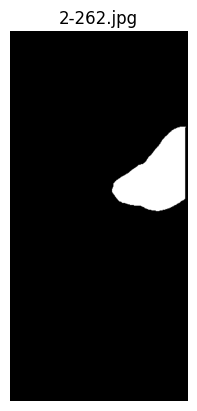

In [3]:
# ===== Step 1: Dataset inspection & mapping =====
import os, glob, random
import pandas as pd
import matplotlib.pyplot as plt
import cv2, pydicom
from collections import Counter

# Path to dataset
DATA_PATH = "/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset"

# 1. List CSV files
csv_files = glob.glob(os.path.join(DATA_PATH, "**", "*.csv"), recursive=True)
print("Found CSVs:")
for f in csv_files:
    print(" -", os.path.relpath(f, DATA_PATH))

# 2. Try loading key CSVs
def safe_load(path):
    try:
        df = pd.read_csv(path)
        print(f"{os.path.basename(path)} -> shape {df.shape}")
        return df
    except Exception as e:
        print("Failed to load", path, e)
        return None

dfs = {}
for f in csv_files:
    name = os.path.splitext(os.path.basename(f))[0]
    dfs[name] = safe_load(f)

# 3. Peek into mass_case_description_train_set.csv
if "mass_case_description_train_set" in dfs:
    display(dfs["mass_case_description_train_set"].head())

# 4. Peek into calc_case_description_train_set.csv
if "calc_case_description_train_set" in dfs:
    display(dfs["calc_case_description_train_set"].head())

# 5. Count benign vs malignant cases in mass + calc
for name in ["mass_case_description_train_set", "mass_case_description_test_set",
             "calc_case_description_train_set", "calc_case_description_test_set"]:
    if name in dfs:
        print(f"\n{name}:")
        if "pathology" in dfs[name].columns:
            print(dfs[name]["pathology"].value_counts())

# 6. List some image files
img_files = glob.glob(os.path.join(DATA_PATH, "**", "*.jpg"), recursive=True)
print(f"\nTotal .jpg images found: {len(img_files)}")
print("Sample paths:", img_files[:5])

# 7. Display random sample image
if img_files:
    sample = random.choice(img_files)
    print("\nSample image:", sample)
    img = cv2.imread(sample, cv2.IMREAD_GRAYSCALE)
    plt.imshow(img, cmap="gray")
    plt.title(os.path.basename(sample))
    plt.axis("off")
    plt.show()


In [4]:
import os, glob

DATA_PATH = "/kaggle/input/cbis-ddsm-breast-cancer-image-dataset"
IMG_ROOT = os.path.join(DATA_PATH, "jpeg")

# Show 5 random folder paths inside jpeg
jpg_dirs = glob.glob(os.path.join(IMG_ROOT, "*"))
print("Number of UID folders:", len(jpg_dirs))
print("Sample folders:", jpg_dirs[:5])

# Show sample jpgs from one folder
if jpg_dirs:
    sample_folder = jpg_dirs[0]
    print("\nSample folder:", sample_folder)
    sample_jpgs = glob.glob(os.path.join(sample_folder, "*.jpg"))
    print("JPG count in this folder:", len(sample_jpgs))
    print("Example jpgs:", sample_jpgs[:5])


Number of UID folders: 0
Sample folders: []


In [5]:
# ===== Step 2 (Correct Merge via StudyInstanceUID) =====
import pandas as pd
import os, glob, re

DATA_PATH = "/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset"
IMG_ROOT = os.path.join(DATA_PATH, "jpeg")

# Load CSVs
mass_train = pd.read_csv(os.path.join(DATA_PATH, "csv/mass_case_description_train_set.csv"))
mass_test  = pd.read_csv(os.path.join(DATA_PATH, "csv/mass_case_description_test_set.csv"))
calc_train = pd.read_csv(os.path.join(DATA_PATH, "csv/calc_case_description_train_set.csv"))
calc_test  = pd.read_csv(os.path.join(DATA_PATH, "csv/calc_case_description_test_set.csv"))
dicom_info = pd.read_csv(os.path.join(DATA_PATH, "csv/dicom_info.csv"))

# Combine case descriptions
all_cases = pd.concat([
    mass_train.assign(case_type="mass", split="train"),
    mass_test.assign(case_type="mass", split="test"),
    calc_train.assign(case_type="calc", split="train"),
    calc_test.assign(case_type="calc", split="test"),
], ignore_index=True)

# Binary labels
def pathology_to_label(p):
    p = str(p).upper()
    if "MALIG" in p:
        return 1
    elif "BENIGN" in p or "NORMAL" in p:
        return 0
    else:
        return None

all_cases["label"] = all_cases["pathology"].apply(pathology_to_label)

# Extract UID from case CSV
def extract_uid(path):
    match = re.search(r"(1\.3\.6\.1\.[0-9\.]+)", str(path))
    return match.group(1) if match else None

all_cases["_study_uid"] = all_cases["image file path"].apply(extract_uid)

print("Sample extracted UID:", all_cases["_study_uid"].dropna().iloc[0])

# Merge with dicom_info on StudyInstanceUID
merged = all_cases.merge(dicom_info, left_on="_study_uid", right_on="StudyInstanceUID", how="inner")

print("\nAfter merge:", merged.shape)
print(merged[["_study_uid","pathology","label","image_path"]].head())

# Final dataset
df_final = merged.dropna(subset=["image_path"]).reset_index(drop=True)
print("\nFinal dataset shape:", df_final.shape)
print(df_final[["patient_id","case_type","split","pathology","label","image_path"]].head())

# Save
df_final.to_csv("/kaggle/working/cbis_master.csv", index=False)


Sample extracted UID: 1.3.6.1.4.1.9590.100.1.2.422112722213189649807611434612228974994

After merge: (3568, 59)
                                          _study_uid  pathology  label  \
0  1.3.6.1.4.1.9590.100.1.2.422112722213189649807...  MALIGNANT      1   
1  1.3.6.1.4.1.9590.100.1.2.319478999311971442426...  MALIGNANT      1   
2  1.3.6.1.4.1.9590.100.1.2.347107867812656628709...     BENIGN      0   
3  1.3.6.1.4.1.9590.100.1.2.272600286511817402806...     BENIGN      0   
4  1.3.6.1.4.1.9590.100.1.2.174047308712169195014...     BENIGN      0   

                                          image_path  
0  CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.342386...  
1  CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.359308...  
2  CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.891800...  
3  CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.295360...  
4  CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.410524...  

Final dataset shape: (3568, 59)
  patient_id case_type  split  pathology  label  \
0    P_00001      mass  train

Class counts: {0: 2111, 1: 1457}


/tmp/ipykernel_38/3464367058.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="coolwarm")


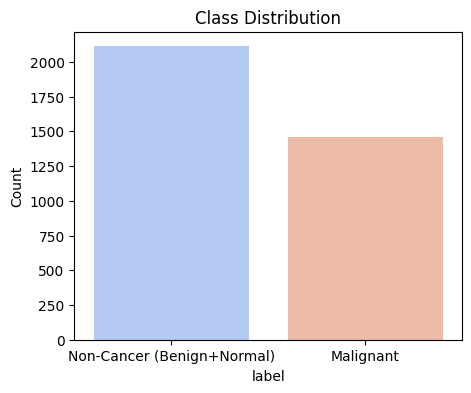


Train split distribution:
label
0    1683
1    1181
Name: count, dtype: int64

Test split distribution:
label
0    428
1    276
Name: count, dtype: int64


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Class distribution
counts = df_final["label"].value_counts().sort_index()
print("Class counts:", counts.to_dict())

plt.figure(figsize=(5,4))
sns.barplot(x=counts.index, y=counts.values, palette="coolwarm")
plt.xticks([0,1], ["Non-Cancer (Benign+Normal)", "Malignant"])
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

# By split (train vs test)
print("\nTrain split distribution:")
print(df_final[df_final["split"]=="train"]["label"].value_counts())

print("\nTest split distribution:")
print(df_final[df_final["split"]=="test"]["label"].value_counts())


In [7]:
# Fix image_path to absolute Kaggle paths
df_final["image_path"] = df_final["image_path"].apply(
    lambda p: os.path.join("/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset", p.replace("CBIS-DDSM/", ""))
)

print(df_final["image_path"].iloc[0])


/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/1-211.jpg


In [8]:
# Rebuild splits
df_trainval = df_final[df_final["split"]=="train"].copy()
df_test     = df_final[df_final["split"]=="test"].copy()

from sklearn.model_selection import train_test_split

df_train, df_val = train_test_split(
    df_trainval,
    test_size=0.40,
    stratify=df_trainval["label"],
    random_state=42
)

print("Train:", df_train.shape)
print("Val:", df_val.shape)
print("Test:", df_test.shape)

# Save again
df_train.to_csv("/kaggle/working/train_final.csv", index=False)
df_val.to_csv("/kaggle/working/val_final.csv", index=False)
df_test.to_csv("/kaggle/working/test_final.csv", index=False)


Train: (1718, 59)
Val: (1146, 59)
Test: (704, 59)


In [9]:
import cv2
import numpy as np
import albumentations as A
from tensorflow.keras.utils import Sequence
from tensorflow.keras.utils import to_categorical


# Image size
IMG_SIZE = 512

# Augmentation pipeline
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.3),
    A.Rotate(limit=10, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.CLAHE(clip_limit=2.0, p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=0, p=0.3),
    A.Resize(IMG_SIZE, IMG_SIZE)
])

val_test_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE)
])

# Custom data generator
# Custom data generator
class MammogramDataset(Sequence):
    def __init__(self, df, batch_size=16, shuffle=True, augment=False):
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.indices = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        batch_indices = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        batch_df = self.df.iloc[batch_indices]

        images, labels = [], []
        for _, row in batch_df.iterrows():
            path = row["image_path"]
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

        # Convert grayscale → RGB
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        # Apply augmentation
            if self.augment:
                img = train_transform(image=img)["image"]
            else:
                img = val_test_transform(image=img)["image"]

        # Normalize
            img = img.astype(np.float32) / 255.0

            images.append(img)
            labels.append(row["label"])

    # ✅ Convert labels to one-hot vectors (shape: (batch,2))
        labels = to_categorical(np.array(labels, dtype="int32"), num_classes=2)

        return np.array(images), labels


# Build generators
BATCH_SIZE = 16
train_gen = MammogramDataset(df_train, batch_size=BATCH_SIZE, shuffle=True, augment=True)
val_gen   = MammogramDataset(df_val, batch_size=BATCH_SIZE, shuffle=False, augment=False)
test_gen  = MammogramDataset(df_test, batch_size=BATCH_SIZE, shuffle=False, augment=False)

# Quick test
x, y = train_gen[0]
print("Batch images shape:", x.shape, "Batch labels shape:", y.shape)


Batch images shape: (16, 512, 512, 3) Batch labels shape: (16, 2)


In [10]:
import os
from tqdm import tqdm
import pandas as pd

# Directory for new malignant images
OUTPUT_DIR = "/kaggle/working/train_balanced_images"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Separate malignant + benign
malignant_df = df_train[df_train["label"]==1].copy()
benign_df = df_train[df_train["label"]==0].copy()

print("Before balancing:")
print("Benign:", benign_df.shape[0], " Malignant:", malignant_df.shape[0])

# How many malignant images we need to generate
needed = benign_df.shape[0] - malignant_df.shape[0]
print("Need to generate:", needed, "extra malignant images")

augmented_rows = []
count = 0

for i, row in tqdm(malignant_df.iterrows(), total=len(malignant_df)):
    if count >= needed:
        break

    img = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Apply augmentation
    aug_img = train_transform(image=img)["image"]

    # Save augmented image
    save_path = os.path.join(OUTPUT_DIR, f"aug_malig_{count}.jpg")
    cv2.imwrite(save_path, cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))

    # Record metadata
    augmented_rows.append({
        "patient_id": row["patient_id"],
        "case_type": row["case_type"],
        "split": "train",
        "pathology": row["pathology"],
        "label": 1,
        "image_path": save_path
    })

    count += 1

# Build balanced train DataFrame
aug_df = pd.DataFrame(augmented_rows)
balanced_train_df = pd.concat([df_train, aug_df], ignore_index=True)

print("\nAfter balancing:")
print(balanced_train_df["label"].value_counts())

# Save final balanced train CSV
balanced_train_df.to_csv("/kaggle/working/train_balanced.csv", index=False)
print("Saved train_balanced.csv with shape:", balanced_train_df.shape)


Before balancing:
Benign: 1010  Malignant: 708
Need to generate: 302 extra malignant images


 43%|████▎     | 302/708 [00:22<00:30, 13.43it/s]



After balancing:
label
0    1010
1    1010
Name: count, dtype: int64
Saved train_balanced.csv with shape: (2020, 59)


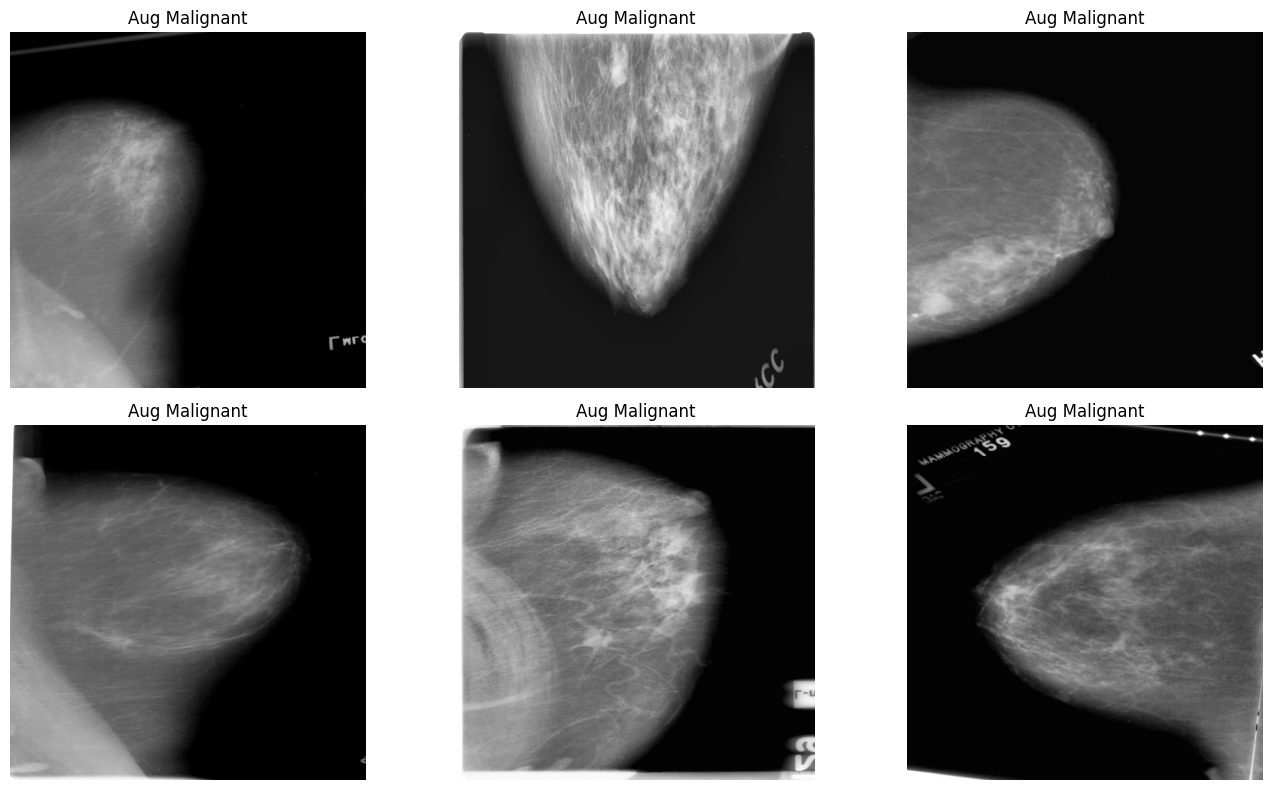

In [11]:
import matplotlib.pyplot as plt

# Display some augmented malignant images
sample_aug = aug_df.sample(6, random_state=42)["image_path"].tolist()

plt.figure(figsize=(14, 8))
for i, path in enumerate(sample_aug, 1):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.title("Aug Malignant")
    plt.axis("off")
plt.tight_layout()
plt.show()


In [12]:
import os, glob

IMG_ROOT = "/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg"

# Count how many UID folders
uid_folders = glob.glob(os.path.join(IMG_ROOT, "*"))
print("Total UID folders in jpeg:", len(uid_folders))
print("Example folder:", uid_folders[0])

# Count how many jpg files total
jpg_files = glob.glob(os.path.join(IMG_ROOT, "**/*.jpg"), recursive=True)
print("Total jpg files:", len(jpg_files))
print("Sample jpgs:", jpg_files[:5])

# Now search if any path looks like 'cropped' or 'mask'
cropped_like = [p for p in jpg_files if "crop" in p.lower() or "roi" in p.lower() or "mask" in p.lower()]
print("ROI/mask-like jpgs found:", len(cropped_like))
print("Examples:", cropped_like[:5])


Total UID folders in jpeg: 6774
Example folder: /kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.426013102412536473840491086280519425818
Total jpg files: 10237
Sample jpgs: ['/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.426013102412536473840491086280519425818/1-223.jpg', '/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.16568542011655175430071162144126831780/2-089.jpg', '/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.16568542011655175430071162144126831780/1-111.jpg', '/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.116437756113164247142539498550746659420/1-051.jpg', '/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.116437756113164247142539498550746659420/2-203.jpg']
ROI/mask-like jpgs

In [13]:
import pandas as pd

DATA_PATH = "/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/csv"

mass_train = pd.read_csv(f"{DATA_PATH}/mass_case_description_train_set.csv")
print("Columns:", mass_train.columns.tolist())
print(mass_train.head(3))


Columns: ['patient_id', 'breast_density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'mass shape', 'mass margins', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']
  patient_id  breast_density left or right breast image view  abnormality id  \
0    P_00001               3                 LEFT         CC               1   
1    P_00001               3                 LEFT        MLO               1   
2    P_00004               3                 LEFT         CC               1   

  abnormality type                          mass shape mass margins  \
0             mass  IRREGULAR-ARCHITECTURAL_DISTORTION   SPICULATED   
1             mass  IRREGULAR-ARCHITECTURAL_DISTORTION   SPICULATED   
2             mass            ARCHITECTURAL_DISTORTION  ILL_DEFINED   

   assessment  pathology  subtlety  \
0           4  MALIGNANT         4   
1           4  MALIGNANT         4   
2           4     BENIGN 

In [14]:
import glob, os

DATA_PATH = "/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset"

# Show sample of image files
all_imgs = glob.glob(os.path.join(DATA_PATH, "**/*.jpg"), recursive=True)
print("Total JPGs:", len(all_imgs))
print("Sample paths:")
for p in all_imgs[:10]:
    print(p)


Total JPGs: 10237
Sample paths:
/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.426013102412536473840491086280519425818/1-223.jpg
/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.16568542011655175430071162144126831780/2-089.jpg
/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.16568542011655175430071162144126831780/1-111.jpg
/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.116437756113164247142539498550746659420/1-051.jpg
/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.116437756113164247142539498550746659420/2-203.jpg
/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.265953197912973660327069359641506533925/1-288.jpg
/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.

In [15]:
print(all_cases["image file path"].head().tolist())
print(all_cases["cropped image file path"].head().tolist())


['Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.422112722213189649807611434612228974994/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/000000.dcm', 'Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.9590.100.1.2.319478999311971442426185353560182990988/1.3.6.1.4.1.9590.100.1.2.359308329312397897125630708681441180834/000000.dcm', 'Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.347107867812656628709864319310977895697/1.3.6.1.4.1.9590.100.1.2.89180046211022531834352631483669346540/000000.dcm', 'Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.9590.100.1.2.272600286511817402806912403581910920939/1.3.6.1.4.1.9590.100.1.2.295360926313492745441868049270168300162/000000.dcm', 'Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.9590.100.1.2.174047308712169195014610267031196524486/1.3.6.1.4.1.9590.100.1.2.410524754913057908920631336070876889890/000000.dcm']
['Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.9590.100.1.2.108268213011361124203859148071588939106/1.3.6.1.4.1.9590.100.1.2.29

In [16]:
import glob, re

DATA_PATH = "/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg"

# Get all JPEGs
all_jpgs = glob.glob(os.path.join(DATA_PATH, "**/*.jpg"), recursive=True)

# Map UID folder → example jpg file
uid_to_jpg = {}
for f in all_jpgs:
    uid = f.split("/")[-2]  # folder name
    if uid not in uid_to_jpg:
        uid_to_jpg[uid] = f  # store one example path

def find_jpg_from_csv(p):
    match = re.findall(r"(1\.3\.6\.1\.[0-9\.]+)", str(p))
    if not match:
        return None
    uid = match[-1]  # take last UID in CSV path
    return uid_to_jpg.get(uid, None)

# Test on first few rows
print(all_cases["image file path"].head().apply(find_jpg_from_csv).tolist())
print(all_cases["cropped image file path"].head().apply(find_jpg_from_csv).tolist())


['/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/1-211.jpg', '/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.359308329312397897125630708681441180834/1-207.jpg', '/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.89180046211022531834352631483669346540/1-250.jpg', '/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.295360926313492745441868049270168300162/1-067.jpg', '/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.410524754913057908920631336070876889890/1-056.jpg']
['/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.296736403313792599626368780122205399650/2-249.jpg', '/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.

In [17]:
all_cases["image_path"] = all_cases["image file path"].apply(find_jpg_from_csv)
all_cases["cropped_path"] = all_cases["cropped image file path"].apply(find_jpg_from_csv)

df_roi = all_cases.dropna(subset=["image_path", "cropped_path"])
print("ROI pairs created:", df_roi.shape)
df_roi.head(3)


ROI pairs created: (3567, 23)


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,...,ROI mask file path,case_type,split,breast density,calc type,calc distribution,label,_study_uid,image_path,cropped_path
0,P_00001,3.0,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,mass,train,NaN,NaN,NaN,1,1.3.6.1.4.1.9590.100.1.2.422112722213189649807...,/kaggle/input/datasets/awsaf49/cbis-ddsm-breas...,/kaggle/input/datasets/awsaf49/cbis-ddsm-breas...
1,P_00001,3.0,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,mass,train,NaN,NaN,NaN,1,1.3.6.1.4.1.9590.100.1.2.319478999311971442426...,/kaggle/input/datasets/awsaf49/cbis-ddsm-breas...,/kaggle/input/datasets/awsaf49/cbis-ddsm-breas...
2,P_00004,3.0,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,mass,train,NaN,NaN,NaN,0,1.3.6.1.4.1.9590.100.1.2.347107867812656628709...,/kaggle/input/datasets/awsaf49/cbis-ddsm-breas...,/kaggle/input/datasets/awsaf49/cbis-ddsm-breas...


In [18]:
# === Robust UID → JPEG mapping ===
import glob, os, re

DATA_PATH = "/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg"

# Collect all JPEGs
all_jpgs = glob.glob(os.path.join(DATA_PATH, "**/*.jpg"), recursive=True)

# Map UID → list of jpgs
uid_to_jpgs = {}
for f in all_jpgs:
    uid = f.split("/")[-2]  # UID folder name
    uid_to_jpgs.setdefault(uid, []).append(f)

def find_jpg_from_csv(p):
    """Match UID from CSV path to actual JPEG in Kaggle folder."""
    match = re.findall(r"(1\.3\.6\.1\.[0-9\.]+)", str(p))
    if not match:
        return None
    uid = match[-1]  # take last UID
    if uid not in uid_to_jpgs:
        return None
    return uid_to_jpgs[uid][0]  # pick first jpg (later we can refine)

# Apply mapping
all_cases["image_path"]   = all_cases["image file path"].apply(find_jpg_from_csv)
all_cases["cropped_path"] = all_cases["cropped image file path"].apply(find_jpg_from_csv)

# Final ROI dataframe
df_roi = all_cases.dropna(subset=["image_path","cropped_path"])
print("ROI pairs created:", df_roi.shape)
print(df_roi.head(3))


ROI pairs created: (3567, 23)
  patient_id  breast_density left or right breast image view  abnormality id  \
0    P_00001             3.0                 LEFT         CC               1   
1    P_00001             3.0                 LEFT        MLO               1   
2    P_00004             3.0                 LEFT         CC               1   

  abnormality type                          mass shape mass margins  \
0             mass  IRREGULAR-ARCHITECTURAL_DISTORTION   SPICULATED   
1             mass  IRREGULAR-ARCHITECTURAL_DISTORTION   SPICULATED   
2             mass            ARCHITECTURAL_DISTORTION  ILL_DEFINED   

   assessment  pathology  ...  \
0           4  MALIGNANT  ...   
1           4  MALIGNANT  ...   
2           4     BENIGN  ...   

                                  ROI mask file path case_type  split  \
0  Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...      mass  train   
1  Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...      mass  train   
2  Mass-Trai

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


In [19]:
# Create binary masks from ROI crops (approximate). Paste after df_roi is created.
import os, cv2, numpy as np
MASK_DIR = "/kaggle/working/generated_masks"
os.makedirs(MASK_DIR, exist_ok=True)

def create_mask_from_crop(crop_path, out_path, size=256):
    # read grayscale or color
    img = cv2.imread(crop_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return False
    # apply CLAHE + Gaussian blur
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_eq = clahe.apply(img)
    blur = cv2.GaussianBlur(img_eq, (5,5), 0)
    # Otsu threshold for mask
    _, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # morphological open to remove noise
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    # resize to fixed size
    mask = cv2.resize(mask, (size,size), interpolation=cv2.INTER_NEAREST)
    cv2.imwrite(out_path, mask)
    return True

# Iterate df_roi to produce masks (only generate if they don't exist)
count=0
for i, row in df_roi.iterrows():
    crop = row.get("cropped_path")  # earlier column
    if not isinstance(crop, str) or not os.path.exists(crop):
        continue
    base = f"mask_{i}.png"
    outp = os.path.join(MASK_DIR, base)
    if os.path.exists(outp):
        continue
    ok = create_mask_from_crop(crop, outp, size=256)
    if ok:
        df_roi.at[i, "mask_path"] = outp
        count += 1
print("Generated masks:", count)
# save updated df_roi with mask_path
df_roi.to_csv("/kaggle/working/df_roi_with_masks.csv", index=False)


/tmp/ipykernel_38/3503186044.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_roi.at[i, "mask_path"] = outp


Generated masks: 3567


In [20]:
import tensorflow as tf

try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver.connect()
    strategy = tf.distribute.TPUStrategy(tpu)
    print("✅ Running on TPU:", tpu.master())
except ValueError:
    strategy = tf.distribute.get_strategy()  # fallback to CPU/GPU
    print("⚠️ Running on:", strategy)


⚠️ Running on: <tensorflow.python.distribute.distribute_lib._DefaultDistributionStrategy object at 0x7dbba47d8810>


In [ ]:
# ---------- Segmentation training + pixel-accuracy only + graphs + visualization ----------
import os, random, numpy as np, pandas as pd, cv2
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# SETTINGS (tweak if OOM)
IMG_SIZE = 192    # reduce to 160 or 128 if OOM
BATCH = 16
EPOCHS_HEAD = 4
EPOCHS_FINE = 2
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE
POS_OVERSAMPLE_FACTOR = 4

random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__, "IMG_SIZE:", IMG_SIZE, "BATCH:", BATCH)

# REQUIRE: df_roi exists with image_path & mask_path
if "df_roi" not in globals():
    raise RuntimeError("df_roi not found. Add df_roi with image_path & mask_path.")

df = df_roi.copy().reset_index(drop=True)
if "mask_path" not in df.columns:
    candidates = [c for c in df.columns if "mask" in c.lower() or "crop" in c.lower()]
    if not candidates:
        raise RuntimeError("Mask column not found. Add mask_path column.")
    df = df.rename(columns={candidates[0]:"mask_path"})

# filter missing files
df = df.dropna(subset=["image_path","mask_path"]).reset_index(drop=True)
df = df[df.apply(lambda r: os.path.exists(str(r["image_path"])) and os.path.exists(str(r["mask_path"])), axis=1)].reset_index(drop=True)
print("ROIs with masks (found & exist):", len(df))

# quick mask positivity check (small resize)
def is_positive_mask(p, sz=64):
    m = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if m is None: return False
    m = cv2.resize(m, (sz,sz))
    return (m > 10).sum() > 0

df["mask_pos"] = df["mask_path"].astype(str).map(lambda p: is_positive_mask(p, sz=64))
pos_df = df[df["mask_pos"]].copy()
neg_df = df[~df["mask_pos"]].copy()
print("Positive masks:", len(pos_df), " Negative (empty) masks:", len(neg_df))

# oversample positives
if len(pos_df) > 0:
    pos_needed = max(len(neg_df), len(pos_df)) * POS_OVERSAMPLE_FACTOR
    if pos_needed > len(pos_df):
        pos_extra = pos_df.sample(pos_needed - len(pos_df), replace=True, random_state=SEED)
        pos_bal = pd.concat([pos_df, pos_extra], ignore_index=True)
    else:
        pos_bal = pos_df.sample(pos_needed, random_state=SEED)
else:
    pos_bal = pos_df

balanced_df = pd.concat([neg_df, pos_bal], ignore_index=True).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
print("Balanced training candidate size:", len(balanced_df))

# Train/Val split
strat = balanced_df["pathology"] if "pathology" in balanced_df.columns else None
train_df_seg, val_df_seg = train_test_split(balanced_df, test_size=0.20, stratify=strat, random_state=SEED)
print("Train/Val:", len(train_df_seg), len(val_df_seg))

# tf.data pipeline
def parse_seg_tf(img_path, mask_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=1)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE]) / 255.0
    img = tf.image.grayscale_to_rgb(img)
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_jpeg(mask, channels=1)
    mask = tf.image.resize(mask, [IMG_SIZE, IMG_SIZE]) / 255.0
    mask = tf.where(mask > 0.5, 1.0, 0.0)
    return img, mask

def aug_fn(img, mask):
    imask = tf.concat([img, mask], axis=-1)
    imask = tf.image.random_flip_left_right(imask)
    imask = tf.image.random_flip_up_down(imask)
    k = tf.random.uniform([], 0, 4, dtype=tf.int32)
    imask = tf.image.rot90(imask, k)
    img = imask[..., :3]
    mask = imask[..., 3:]
    img = tf.image.random_brightness(img, 0.06)
    img = tf.image.random_contrast(img, 0.95, 1.05)
    return img, mask

def make_ds(df, batch=BATCH, shuffle=True, augment=False):
    imgs = df["image_path"].astype(str).values
    masks = df["mask_path"].astype(str).values
    ds = tf.data.Dataset.from_tensor_slices((imgs, masks))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(imgs), seed=SEED)
    ds = ds.map(lambda p,m: parse_seg_tf(p,m), num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(aug_fn, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(train_df_seg, batch=BATCH, shuffle=True, augment=True)
val_ds   = make_ds(val_df_seg, batch=BATCH, shuffle=False, augment=False)

# Build MobileNetV2 UNet (same improved decoder)
def up(x, skip, f):
    x = layers.UpSampling2D((2,2), interpolation="bilinear")(x)
    x = layers.Concatenate()([x, skip])
    x = layers.Conv2D(f, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(f, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

base = tf.keras.applications.MobileNetV2(input_shape=(IMG_SIZE,IMG_SIZE,3), include_top=False, weights="imagenet")
skip_names = ["block_3_expand_relu","block_6_expand_relu","block_13_expand_relu"]
skips = [base.get_layer(n).output for n in skip_names]
enc_out = base.output

x = layers.Conv2D(512, 3, padding="same", activation="relu")(enc_out)
x = up(x, skips[-1], 256)
x = up(x, skips[-2], 128)
x = up(x, skips[-3], 64)
x = layers.UpSampling2D((2,2), interpolation="bilinear")(x)
x = layers.Conv2D(32,3,padding="same", use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.Lambda(lambda z: tf.image.resize(z, [IMG_SIZE, IMG_SIZE], method='bilinear'))(x)
out = layers.Conv2D(1,1, activation='sigmoid')(x)
model = models.Model(inputs=base.input, outputs=out, name="MobileNetV2_UNet_pixelacc")

# freeze encoder for head training
for lay in base.layers:
    lay.trainable = False

# Loss: keep improved_loss but metric only pixel_accuracy
def weighted_bce(y_true, y_pred, pos_w=1.0, eps=1e-7):
    y_true_f = tf.cast(y_true, tf.float32)
    bce = -(y_true_f * tf.math.log(tf.clip_by_value(y_pred, eps, 1.0)) * pos_w +
            (1.0 - y_true_f) * tf.math.log(tf.clip_by_value(1.0 - y_pred, eps, 1.0)))
    return tf.reduce_mean(bce)

def tversky(y_true, y_pred, alpha=0.45, beta=0.55, smooth=1e-6):
    y_t = tf.reshape(y_true, [-1])
    y_p = tf.reshape(y_pred, [-1])
    TP = tf.reduce_sum(y_t * y_p)
    FP = tf.reduce_sum((1 - y_t) * y_p)
    FN = tf.reduce_sum(y_t * (1 - y_p))
    t = (TP + smooth) / (TP + alpha*FP + beta*FN + smooth)
    return t

def focal_tversky(y_true, y_pred, gamma=0.75):
    t = tversky(y_true, y_pred)
    return tf.pow((1.0 - t), gamma)

def improved_loss(y_true, y_pred):
    # pos weight roughly 1 here; oversampling already used
    wb = weighted_bce(y_true, y_pred, pos_w=1.0)
    ft = focal_tversky(y_true, y_pred, gamma=0.75)
    return 0.5*wb + 0.5*ft

# Pixel accuracy metric only
def pixel_accuracy(y_true, y_pred):
    y_pred_bin = tf.cast(y_pred >= 0.5, tf.float32)
    return tf.reduce_mean(tf.cast(tf.equal(tf.cast(y_true, tf.float32), y_pred_bin), tf.float32))

model.compile(optimizer=optimizers.Adam(1e-3), loss=improved_loss, metrics=[pixel_accuracy])
model.summary()
print("Compiled with metric: pixel_accuracy only")

# callbacks (monitor pixel_accuracy)
out_path = "/kaggle/working/mobilenetv2_unet_pixelacc_best.keras"
cbs = [
    callbacks.ModelCheckpoint(out_path, monitor="val_pixel_accuracy", mode="max", save_best_only=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_pixel_accuracy", factor=0.5, patience=2, mode="max", verbose=1),
    callbacks.EarlyStopping(monitor="val_pixel_accuracy", patience=4, mode="max", restore_best_weights=True, verbose=1)
]

# Train decoder head
print("Training decoder head (encoder frozen)...")
history_head = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD, callbacks=cbs, verbose=2)

# Fine-tune last encoder layers
print("Fine-tuning last encoder layers...")
for lay in base.layers:
    lay.trainable = False
for lay in base.layers[-30:]:
    lay.trainable = True

model.compile(optimizer=optimizers.Adam(1e-4), loss=improved_loss, metrics=[pixel_accuracy])
history_fine = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FINE, callbacks=cbs, verbose=2)

# Combine histories
def combine_histories(h1, h2):
    out = {}
    for k in h1.history:
        out[k] = h1.history[k] + (h2.history[k] if (h2 and k in h2.history) else [])
    return out

hist = combine_histories(history_head, history_fine)

# Final validation accuracy (pixel)
val_accs = []
for xb, yb in val_ds:
    p = model.predict(xb, verbose=0)
    pbin = (p >= 0.5).astype(np.uint8)
    y_true = yb.numpy().astype(np.uint8)
    val_accs.append((pbin == y_true).mean())
print("Final Pixel accuracy (val) mean:", float(np.mean(val_accs)))

# ---------- Plots: loss and pixel_accuracy ----------
epochs = range(1, len(hist['loss'])+1)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs, hist['loss'], label='train loss')
if 'val_loss' in hist: plt.plot(epochs, hist['val_loss'], label='val loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss'); plt.legend()
plt.subplot(1,2,2)
plt.plot(epochs, hist['pixel_accuracy'], label='train pixel_acc')
if 'val_pixel_accuracy' in hist: plt.plot(epochs, hist['val_pixel_accuracy'], label='val pixel_acc')
plt.xlabel('Epoch'); plt.ylabel('Pixel Accuracy'); plt.title('Pixel Accuracy'); plt.legend()
plt.tight_layout()
plt.show()

# ---------- Visualization: show 3 examples from validation set ----------
def overlay_mask_on_image(img, mask, color=(255,0,0), alpha=0.5):
    # img: HxWx3 uint8, mask: HxW uint8 0/255
    colored = img.copy()
    mask_bool = (mask>127)
    colored[mask_bool] = (colored[mask_bool] * (1-alpha) + np.array(color)*(alpha)).astype(np.uint8)
    return colored

print("Showing 3 validation examples (Image | GT | Pred | Overlay)")
n_show = 3
cnt = 0
for xb, yb in val_ds.unbatch().batch(1).take(200):  # sample up to 200 val items; change if needed
    xb_np = (xb[0].numpy()*255).astype(np.uint8)
    gt_np = (yb[0].numpy().squeeze()*255).astype(np.uint8)
    pred = model.predict(xb, verbose=0)[0]
    pred_bin = (pred.squeeze() >= 0.5).astype(np.uint8)*255

    overlay = overlay_mask_on_image(xb_np, pred_bin, color=(255,0,0), alpha=0.5)

    fig, ax = plt.subplots(1,4, figsize=(16,4))
    ax[0].imshow(xb_np); ax[0].set_title("Image"); ax[0].axis('off')
    ax[1].imshow(gt_np, cmap='gray'); ax[1].set_title("GT Mask"); ax[1].axis('off')
    ax[2].imshow(pred_bin, cmap='gray'); ax[2].set_title("Pred Mask (0.5)"); ax[2].axis('off')
    ax[3].imshow(overlay); ax[3].set_title("Overlay (pred in red)"); ax[3].axis('off')
    plt.show()

    cnt += 1
    if cnt >= n_show:
        break

# Save final model
final_path = "/kaggle/working/mobilenetv2_unet_pixelacc_final.keras"
model.save(final_path)
print("Saved model to:", final_path)


TensorFlow: 2.15.0 IMG_SIZE: 192 BATCH: 16
ROIs with masks (found & exist): 3567
Positive masks: 3562  Negative (empty) masks: 5
Balanced training candidate size: 14253
Train/Val: 11402 2851
9406464/9406464 [==============================] - 0s 0us/step
Model: "MobileNetV2_UNet_pixelacc"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 192, 192, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 96, 96, 32)           864       ['input_1[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 96, 96, 32)           128       ['Conv1[0][0]']               
 on)              

In [ ]:
# ---------------- Save final model ----------------
final_path = "/kaggle/working/mobilenetv2_unet_pixelacc_final.keras"
model.save(final_path)
print("Saved model to:", final_path)

# ---------------- Save predicted masks for train/val ----------------
PRED_MASK_DIR = "/kaggle/working/pred_masks"
os.makedirs(PRED_MASK_DIR, exist_ok=True)

def save_pred_mask(img_path, out_path, model=model, img_size=IMG_SIZE, thresh=0.5):
    """Run the trained segmentation model on a single image and save binary mask."""
    # same preprocessing as parse_seg_tf (no preprocess_input here)
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=1)
    img = tf.image.resize(img, [img_size, img_size]) / 255.0
    img = tf.image.grayscale_to_rgb(img)             # (H, W, 3)
    x = tf.expand_dims(img, 0)                       # (1, H, W, 3)

    pred = model.predict(x, verbose=0)[0]            # (H, W, 1)
    if pred.ndim == 3:
        pred = pred[..., 0]

    mask = (pred >= thresh).astype(np.uint8) * 255   # 0/255 uint8
    cv2.imwrite(out_path, mask)
    return out_path

def generate_pred_masks_for_df(df, out_dir=PRED_MASK_DIR, prefix="pred"):
    df = df.copy().reset_index(drop=True)
    pred_paths = []
    for i, row in df.iterrows():
        imgp = row["image_path"]
        outp = os.path.join(out_dir, f"{prefix}_{i}.png")
        if not os.path.exists(outp):
            save_pred_mask(imgp, outp)
        pred_paths.append(outp)
    df["pred_mask_path"] = pred_paths
    return df

# generate for train and val sets
train_df_pred = generate_pred_masks_for_df(train_df_seg, prefix="train")
val_df_pred   = generate_pred_masks_for_df(val_df_seg,   prefix="val")

# Optionally save them to CSV for classifier stage
train_df_pred.to_csv("/kaggle/working/train_with_pred_masks.csv", index=False)
val_df_pred.to_csv("/kaggle/working/val_with_pred_masks.csv", index=False)
print("Saved predicted masks for train/val and CSVs.")


In [ ]:
from sklearn.metrics import jaccard_score
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def evaluate_seg_on_df(df, model=model, img_size=IMG_SIZE, thresh=0.5, n=50):
    dices=[]
    ious=[]
    
    for i, row in df.head(n).iterrows():

        imgp = row["image_path"]
        gt_mask_p = row["mask_path"]

        # Load GT
        gt = cv2.imread(gt_mask_p, cv2.IMREAD_GRAYSCALE)
        gt = cv2.resize(gt, (img_size, img_size)) // 255

        # Predict
        x = tf.image.decode_jpeg(tf.io.read_file(imgp), channels=1)
        x = tf.image.resize(x, [img_size, img_size]) / 255.0
        x3 = tf.image.grayscale_to_rgb(x)
        x3 = preprocess_input(tf.expand_dims(x3,0))

        pred = model.predict(x3, verbose=0)[0]
        if pred.ndim == 3:
            pred = pred[...,0]

        pred_bin = (pred >= thresh).astype(np.uint8)

        # Dice
        inter = (pred_bin & (gt>0)).sum()
        denom = pred_bin.sum() + (gt>0).sum()
        dice = (2*inter)/(denom+1e-6)

        # IoU
        iou = jaccard_score(gt.flatten(), pred_bin.flatten(), average='binary', zero_division=0)

        dices.append(dice)
        ious.append(iou)

    print("Val mean Dice:", np.mean(dices), " median:", np.median(dices))
    print("Val mean IoU :", np.mean(ious))

    return dices, ious


# RUN
dices, ious = evaluate_seg_on_df(val_df_seg, model=model, img_size=IMG_SIZE)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_unet(input_shape=(256, 256, 1)):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = layers.Conv2D(64, 3, activation="relu", padding="same")(inputs)
    c1 = layers.Conv2D(64, 3, activation="relu", padding="same")(c1)
    p1 = layers.MaxPooling2D(2)(c1)

    c2 = layers.Conv2D(128, 3, activation="relu", padding="same")(p1)
    c2 = layers.Conv2D(128, 3, activation="relu", padding="same")(c2)
    p2 = layers.MaxPooling2D(2)(c2)

    c3 = layers.Conv2D(256, 3, activation="relu", padding="same")(p2)
    c3 = layers.Conv2D(256, 3, activation="relu", padding="same")(c3)
    p3 = layers.MaxPooling2D(2)(c3)

    c4 = layers.Conv2D(512, 3, activation="relu", padding="same")(p3)
    c4 = layers.Conv2D(512, 3, activation="relu", padding="same")(c4)
    p4 = layers.MaxPooling2D(2)(c4)

    # Bottleneck
    b = layers.Conv2D(1024, 3, activation="relu", padding="same")(p4)
    b = layers.Conv2D(1024, 3, activation="relu", padding="same")(b)

    # Decoder
    u1 = layers.Conv2DTranspose(512, 2, strides=2, padding="same")(b)
    u1 = layers.concatenate([u1, c4])
    c5 = layers.Conv2D(512, 3, activation="relu", padding="same")(u1)
    c5 = layers.Conv2D(512, 3, activation="relu", padding="same")(c5)

    u2 = layers.Conv2DTranspose(256, 2, strides=2, padding="same")(c5)
    u2 = layers.concatenate([u2, c3])
    c6 = layers.Conv2D(256, 3, activation="relu", padding="same")(u2)
    c6 = layers.Conv2D(256, 3, activation="relu", padding="same")(c6)

    u3 = layers.Conv2DTranspose(128, 2, strides=2, padding="same")(c6)
    u3 = layers.concatenate([u3, c2])
    c7 = layers.Conv2D(128, 3, activation="relu", padding="same")(u3)
    c7 = layers.Conv2D(128, 3, activation="relu", padding="same")(c7)

    u4 = layers.Conv2DTranspose(64, 2, strides=2, padding="same")(c7)
    u4 = layers.concatenate([u4, c1])
    c8 = layers.Conv2D(64, 3, activation="relu", padding="same")(u4)
    c8 = layers.Conv2D(64, 3, activation="relu", padding="same")(c8)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(c8)

    return models.Model(inputs, outputs, name="U_Net")

# Build model
unet = build_unet()
unet.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
unet.summary()


In [ ]:
from sklearn.model_selection import train_test_split

# Train/Val split for segmentation
train_df, val_df = train_test_split(
    df_roi,
    test_size=0.4,
    random_state=42,
    stratify=df_roi["pathology"]   # keep benign/malignant balance
)

print("Train size:", train_df.shape, " Val size:", val_df.shape)


In [ ]:
IMG_SIZE = 256
AUTO = tf.data.AUTOTUNE

def parse_image_mask(img_path, mask_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=1)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_jpeg(mask, channels=1)
    mask = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE)) / 255.0
    mask = tf.where(mask > 0.5, 1.0, 0.0)  # binarize
    return img, mask

def build_dataset(df, batch_size=32, shuffle=True):
    dataset = tf.data.Dataset.from_tensor_slices((df["image_path"].values, df["cropped_path"].values))
    dataset = dataset.map(parse_image_mask, num_parallel_calls=AUTO)
    if shuffle:
        dataset = dataset.shuffle(1024)
    return dataset.batch(batch_size).prefetch(AUTO)


# Build datasets
train_ds = build_dataset(train_df, batch_size=64, shuffle=True)   # TPU likes big batches
val_ds   = build_dataset(val_df, batch_size=64, shuffle=False)


In [ ]:
def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.*intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def iou_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])    
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    total = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f)
    union = total - intersection
    return (intersection + smooth) / (union + smooth)

# Re-compile U-Net with better metrics
with strategy.scope():
    unet = build_unet(input_shape=(256,256,1))
    unet.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy", dice_coef, iou_coef])


In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("/kaggle/working/unet_best.h5", save_best_only=True)
]     

history = unet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=2,
    callbacks=callbacks,
    verbose=1
)

In [ ]:
### import matplotlib.pyplot as plt

sample_x, sample_y = next(iter(val_ds))
pred_y = unet.predict(sample_x)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(sample_x[0].numpy().squeeze(), cmap="gray"); plt.title("Image")
plt.subplot(1,3,2); plt.imshow(sample_y[0].numpy().squeeze(), cmap="gray"); plt.title("Ground Truth")
plt.subplot(1,3,3); plt.imshow(pred_y[0].squeeze(), cmap="gray"); plt.title("Predicted Mask")
plt.show()


In [ ]:
# =========================
# === RACapsNet: CLASSIFICATION CONTINUATION
# =========================

# 1) Setup: ensure float32 policy (avoid mixed_float16 issues with custom layers)
import tensorflow as tf, numpy as np, os
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, balanced_accuracy_score, roc_auc_score

tf.keras.mixed_precision.set_global_policy("float32")  # safe for capsule ops

# 2) Pick the dataframes created earlier (robust fallbacks)
try:
    train_df = balanced_train_df  # prefer balanced augmented train
    print("Using balanced_train_df for training (augmented).")
except NameError:
    try:
        train_df = df_train
        print("Using df_train for training.")
    except NameError:
        raise RuntimeError("No training dataframe found (balanced_train_df or df_train).")

# validation/test selection
if 'df_val' in globals():
    val_df = df_val
elif 'val_df' in globals():
    val_df = val_df
else:
    raise RuntimeError("No validation dataframe found (df_val or val_df).")

if 'df_test' in globals():
    test_df = df_test
elif 'df_final' in globals() and 'split' in df_final.columns:
    test_df = df_final[df_final['split']=='test']
else:
    test_df = None  # optional

# 3) Parameters
IMG_SIZE = 224        # classification image size
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
RANDOM_SEED = 42
NUM_CLASSES = 2
BASE_LR = 3e-4
EPOCHS_HEAD = 8
EPOCHS_FINE = 12
LABEL_SMOOTH = 0.05
MIXUP_ALPHA = 0.15

# 4) TF-only dataset builder (returns (image, onehot))
def _read_and_preprocess(path, label, img_size=IMG_SIZE, augment=False):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)  # [0,1]
    img = tf.image.resize(img, [img_size, img_size])

    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.08)
        img = tf.image.random_contrast(img, 0.9, 1.1)
        k = tf.random.uniform([], 0, 4, dtype=tf.int32)
        img = tf.image.rot90(img, k)
        img = tf.clip_by_value(img, 0.0, 1.0)

    return img, tf.one_hot(label, depth=NUM_CLASSES, dtype=tf.float32)

def make_ds(df, batch_size=BATCH_SIZE, augment=False, shuffle=True, mixup=False):
    paths = df["image_path"].astype(str).values
    labels = df["label"].astype(np.int32).values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=RANDOM_SEED)
    ds = ds.map(lambda p,l: _read_and_preprocess(p,l,augment=augment), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    if mixup:
        ds = ds.map(lambda x,y: mixup_batch_tf(x,y,alpha=MIXUP_ALPHA), num_parallel_calls=AUTOTUNE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

# pure-TF mixup (re-include; safe)
def mixup_batch_tf(images, labels, alpha=0.2):
    if alpha <= 0:
        return images, labels
    batch_size = tf.shape(images)[0]
    idx = tf.random.shuffle(tf.range(batch_size))
    images2 = tf.gather(images, idx)
    labels2 = tf.gather(labels, idx)
    g1 = tf.random.gamma([batch_size], alpha)
    g2 = tf.random.gamma([batch_size], alpha)
    lam = g1 / (g1 + g2)
    lam_x = tf.reshape(lam, [batch_size, 1, 1, 1])
    lam_y = tf.reshape(lam, [batch_size, 1])
    mixed_images = images * lam_x + images2 * (1.0 - lam_x)
    mixed_labels = labels * lam_y + labels2 * (1.0 - lam_y)
    return mixed_images, mixed_labels

# Build tf.data datasets
train_ds = make_ds(train_df, batch_size=BATCH_SIZE, augment=True, shuffle=True, mixup=True)
val_ds   = make_ds(val_df, batch_size=BATCH_SIZE, augment=False, shuffle=False, mixup=False)
test_ds  = make_ds(test_df, batch_size=BATCH_SIZE, augment=False, shuffle=False, mixup=False) if test_df is not None else None

# Sanity check
for xb, yb in train_ds.take(1):
    print("train batch images:", xb.shape, " labels:", yb.shape)
for xb, yb in val_ds.take(1):
    print("val batch images:", xb.shape, " labels:", yb.shape)

# 5) Capsule layers (robust to dynamic shapes) - same as your fixed version
from tensorflow.keras import layers

class PrimaryCaps(layers.Layer):
    def __init__(self, caps, dim_caps, kernel=3, strides=1, **kwargs):
        super().__init__(**kwargs)
        self.caps = caps
        self.dim_caps = dim_caps
        self.conv = layers.Conv2D(caps * dim_caps, kernel, strides=strides, padding='same', activation='relu')

    def squash(self, s, axis=-1):
        s_squared_norm = tf.reduce_sum(tf.square(s), axis=axis, keepdims=True)
        scale = s_squared_norm / (1.0 + s_squared_norm) / (tf.sqrt(s_squared_norm + 1e-9))
        return scale * s

    def call(self, inputs):
        x = self.conv(inputs)
        shape = tf.shape(x)
        x = tf.reshape(x, [shape[0], -1, self.dim_caps])
        return self.squash(x)

class DigitCaps(layers.Layer):
    def __init__(self, num_caps_out, dim_out, routing_iters=3, **kwargs):
        super().__init__(**kwargs)
        self.num_caps_out = num_caps_out
        self.dim_out = dim_out
        self.routing_iters = routing_iters
        self.proj = None

    def build(self, input_shape):
        dim_in = int(input_shape[-1])
        self.proj = layers.Dense(self.num_caps_out * self.dim_out, name=self.name + "_proj")
        super().build(input_shape)

    def squash(self, s, axis=-1):
        s_squared_norm = tf.reduce_sum(tf.square(s), axis=axis, keepdims=True)
        scale = s_squared_norm / (1.0 + s_squared_norm) / (tf.sqrt(s_squared_norm + 1e-9))
        return scale * s

    def call(self, u):
        B = tf.shape(u)[0]
        n_in = tf.shape(u)[1]
        u_proj = self.proj(u)  # (B, n_in, n_out * dim_out)
        u_hat = tf.reshape(u_proj, [B, n_in, self.num_caps_out, self.dim_out])
        b = tf.zeros([B, n_in, self.num_caps_out], dtype=tf.float32)
        for i in range(self.routing_iters):
            c = tf.nn.softmax(b, axis=2)
            c_exp = tf.expand_dims(c, -1)
            s = tf.reduce_sum(c_exp * u_hat, axis=1)
            v = self.squash(s)
            if i < self.routing_iters - 1:
                v_exp = tf.expand_dims(v, 1)
                agreement = tf.reduce_sum(u_hat * v_exp, axis=-1)
                b += agreement
        return v

# 6) Build RACapsNet (EfficientNetB0 backbone) — returns probabilities (B, NUM_CLASSES)
def build_racapsnet(img_size=IMG_SIZE, num_classes=2, backbone_weights='imagenet'):
    inp = layers.Input(shape=(img_size, img_size, 3))
    # Use EfficientNetB0 backbone (exclude top)
    base = tf.keras.applications.EfficientNetB0(include_top=False, weights=backbone_weights, input_tensor=inp)
    x = base.output  # e.g. (B, 7, 7, 1280)
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    p = PrimaryCaps(caps=32, dim_caps=8, kernel=3, strides=1)(x)
    d = DigitCaps(num_caps_out=num_classes, dim_out=16, routing_iters=3)(p)  # (B, num_classes, 16)
    lengths = tf.sqrt(tf.reduce_sum(tf.square(d), axis=2) + 1e-9)  # (B, num_classes)
    probs = layers.Softmax(name='probs')(lengths)
    model = models.Model(inputs=inp, outputs=probs, name="RACapsNet_EffB0")
    return model

# 7) Instantiate model under strategy if used (you already set `strategy` earlier)
try:
    strategy
except NameError:
    strategy = tf.distribute.get_strategy()

with strategy.scope():
    model = build_racapsnet(img_size=IMG_SIZE, num_classes=NUM_CLASSES, backbone_weights='imagenet')
    # freeze backbone initially
    for layer in model.layers:
        if layer.name.startswith("efficientnet") or "stem" in layer.name or "rescaling" in layer.name:
            layer.trainable = False

    # compile: label smoothing to stabilize; gradient clipping avoids NaNs
    loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH)
    opt = tf.keras.optimizers.Adam(learning_rate=BASE_LR, clipnorm=1.0)
    model.compile(optimizer=opt, loss=loss_fn, metrics=[tf.keras.metrics.CategoricalAccuracy(name="acc")])

model.summary()

# 8) Callbacks
out_dir = "/kaggle/working/models"
os.makedirs(out_dir, exist_ok=True)
ckpt_path = os.path.join(out_dir, "racaps_best.keras")  # recommended native format
cb = [
    tf.keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_acc", save_best_only=True, mode="max", verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_acc", factor=0.5, patience=3, verbose=1, mode="max"),
    tf.keras.callbacks.EarlyStopping(monitor="val_acc", patience=6, mode="max", restore_best_weights=True, verbose=1)
]

# 9) Train head (top) first
print("Training head (frozen backbone)...")
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=cb,
    verbose=2
)

# 10) Unfreeze last N layers of backbone for fine-tuning
# heuristic: unfreeze last EfficientNet blocks
with strategy.scope():
    # unfreeze whole model for simplicity (or pick last N)
    for layer in model.layers:
        layer.trainable = True
    opt_fine = tf.keras.optimizers.Adam(learning_rate=BASE_LR * 0.2, clipnorm=1.0)
    model.compile(optimizer=opt_fine, loss=loss_fn, metrics=[tf.keras.metrics.CategoricalAccuracy(name="acc")])

print("Fine-tuning all layers...")
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    callbacks=cb,
    verbose=2
)

# 11) Evaluate & print metrics on validation (and test if present)
def evaluate_model(model, ds):
    preds = []
    trues = []
    for xb, yb in ds:
        p = model.predict(xb, verbose=0)
        preds.append(p)
        trues.append(yb.numpy())
    preds = np.vstack(preds)
    trues = np.vstack(trues)
    y_true = np.argmax(trues, axis=1)
    y_pred = np.argmax(preds, axis=1)
    proba_pos = preds[:,1] if preds.shape[1] > 1 else preds[:,0]
    print("Acc:", np.mean(y_true==y_pred))
    print("Balanced:", balanced_accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, zero_division=0))
    print("Recall:", recall_score(y_true, y_pred, zero_division=0))
    print("F1:", f1_score(y_true, y_pred, zero_division=0))
    try:
        print("AUC:", roc_auc_score(y_true, proba_pos))
    except Exception as e:
        print("AUC: - (error)", e)
    print("Confusion:\n", confusion_matrix(y_true, y_pred))
    return preds, trues

print("\nValidation evaluation:")
preds_val, trues_val = evaluate_model(model, val_ds)

if test_df is not None:
    print("\nTest evaluation:")
    preds_test, trues_test = evaluate_model(model, test_ds)

# 12) Save final model (already best saved by checkpoint). Also export a small inference helper
final_save = os.path.join(out_dir, "racaps_final.keras")
model.save(final_save)
print("Saved final model to:", final_save)

# 13) Inference helper example (predict one path)
def predict_single(path, model_path=final_save, img_size=IMG_SIZE):
    m = tf.keras.models.load_model(model_path, custom_objects={"PrimaryCaps":PrimaryCaps, "DigitCaps":DigitCaps}, compile=False)
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, [img_size, img_size])
    x = tf.expand_dims(img, 0)
    p = m.predict(x)
    return p[0]

# Example usage:
# print(predict_single(train_df["image_path"].iloc[0]))


# ========== Notes & troubleshooting ==========

# 1) If you see `loss: nan`:
#    - check dataset for corrupted images (tf.io.read_file failures). I used tf.image.decode_jpeg which will raise on bad files.
#    - try reducing LR and set clipnorm (we included clipnorm=1.0).
#    - try removing mixup (mixup=False) to debug.
# 2) If performance is low:
#    - increase IMG_SIZE to 320 or 380, increase batch size if memory allows.
#    - train longer, apply class-weighting or oversampling (we used balanced_train_df already).
#    - try backbone_weights=None if shapes mismatch with Kaggle TF version (but Imagenet helps).
# 3) Getting >95% depends on data quantity & difficulty — try additional augmentations, ensembling, or stratified k-fold + model ensembling.


In [ ]:
import os, cv2, numpy as np, matplotlib.pyplot as plt, tensorflow as tf

# 1) safe model loaders (use in-memory if exists else from disk)
def load_seg_model(path="/kaggle/working/unet_best.h5"):
    global unet
    try:
        unet  # if defined
    except NameError:
        if os.path.exists(path):
            unet = tf.keras.models.load_model(path, compile=False)
            print("Loaded unet from", path)
        else:
            raise RuntimeError("Segmentation model `unet` not found in memory or on disk at: " + path)
    return unet

def load_clf_model(path=None):
    global model
    if path is None:
        # prefer `model` if present, else final_save var
        if 'model' in globals():
            return model
        if 'final_save' in globals() and os.path.exists(final_save):
            path = final_save
    if path is not None and os.path.exists(path):
        model = tf.keras.models.load_model(path, custom_objects={"PrimaryCaps":globals().get("PrimaryCaps"), "DigitCaps":globals().get("DigitCaps")}, compile=False)
        print("Loaded clf from", path)
        return model
    if 'model' in globals():
        return model
    raise RuntimeError("Classification model not found. Provide path or ensure `model` exists.")

# 2) find last conv2d layer name (for Grad-CAM)
def find_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise RuntimeError("No Conv2D layer found in model; specify layer name manually.")

# 3) preprocess an image path to model input
def preprocess_image(path, img_size=224):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, [img_size, img_size])
    return img  # float32 [0,1]

# 4) get binary mask from unet prediction (thresholding)
def get_seg_mask(path, seg_model=None, img_size=256, threshold=0.5):
    if seg_model is None:
        seg_model = load_seg_model()
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=1)   # unet trained on single-channel
    img = tf.image.resize(img, [img_size, img_size]) / 255.0
    x = tf.expand_dims(img, 0)  # (1,H,W,1)
    pred = seg_model.predict(x, verbose=0)[0]     # (H,W,1) or (H,W)
    if pred.ndim==3:
        pred = pred[...,0]
    mask = (pred >= threshold).astype(np.float32)
    return mask  # numpy array HxW in {0,1}


In [ ]:
def make_gradcam_heatmap(img_tensor, model, last_conv_layer_name=None, class_index=None):
    """
    img_tensor: tf.Tensor shape (1,H,W,3), values in [0,1]
    model: classification model returning softmax probabilities
    class_index: target class index (int). If None, uses top predicted class.
    returns: heatmap (H,W) normalized 0..1 (numpy)
    """
    if last_conv_layer_name is None:
        last_conv_layer_name = find_last_conv_layer(model)

    # Build a model that maps the input to the activations + predictions
    last_conv_layer = model.get_layer(last_conv_layer_name)
    # model may include multiple outputs; get probs output name or assume last
    grad_model = tf.keras.models.Model([model.inputs], [last_conv_layer.output, model.output])

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_tensor)
        if class_index is None:
            class_index = tf.argmax(preds[0])
        class_channel = preds[:, class_index]

    # compute gradients of the target class wrt conv outputs
    grads = tape.gradient(class_channel, conv_outputs)
    # global average pooling of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]
    # weight the conv outputs by pooled grads
    weighted = conv_outputs * pooled_grads[tf.newaxis, tf.newaxis, :]
    cam = tf.reduce_sum(weighted, axis=-1).numpy()
    cam = np.maximum(cam, 0)  # relu
    cam = cam - cam.min() if cam.max() != cam.min() else cam
    cam = cam / (cam.max() + 1e-8)
    cam = cv2.resize(cam, (img_tensor.shape[2], img_tensor.shape[1]))
    return cam

# helper: make heatmap colors and overlay
def heatmap_to_color(cam, colormap=cv2.COLORMAP_JET):
    hm = np.uint8(255 * cam)
    hm_color = cv2.applyColorMap(hm, colormap)
    hm_color = cv2.cvtColor(hm_color, cv2.COLOR_BGR2RGB)
    return hm_color

def overlay_heatmap_on_image(orig_img, heatmap, alpha=0.45):
    # orig_img: float [0,1] HxWx3 ; heatmap: HxW in 0..1
    hm_color = heatmap_to_color(heatmap)
    orig_uint = np.uint8(orig_img*255)
    overlay = np.uint8(orig_uint*(1-alpha) + hm_color*alpha)
    return hm_color, overlay


In [ ]:
def generate_masked_gradcam(path,
                            seg_model=None, clf_model=None,
                            seg_size=256, clf_size=224,
                            seg_threshold=0.5,
                            out_dir="/kaggle/working/gradcam_segmented",
                            target_class=None):
    os.makedirs(out_dir, exist_ok=True)
    seg_model = seg_model or load_seg_model()
    clf_model = clf_model or load_clf_model()
    # 1) original images (resized for display and for models)
    orig_for_seg = tf.image.resize(tf.image.decode_jpeg(tf.io.read_file(path), channels=1), [seg_size, seg_size]) / 255.0
    orig_for_clf = tf.image.resize(tf.image.decode_jpeg(tf.io.read_file(path), channels=3), [clf_size, clf_size]) / 255.0

    orig_rgb = orig_for_clf.numpy()
    # 2) segmentation mask (HxW)
    mask = get_seg_mask(path, seg_model=seg_model, img_size=seg_size, threshold=seg_threshold)
    # 3) upsample mask to classifier size
    mask_resized = cv2.resize(mask, (clf_size, clf_size))
    mask_resized = (mask_resized > 0.5).astype(np.float32)

    # 4) masked image (zero-out background) — keep as float32 [0,1]
    masked_img = orig_rgb * mask_resized[..., None]

    # 5) prepare batches
    inp_full = tf.expand_dims(orig_rgb, 0)
    inp_masked = tf.expand_dims(masked_img, 0)

    # 6) pick last conv
    last_conv = None
    try:
        last_conv = find_last_conv_layer(clf_model)
    except Exception as e:
        print("Couldn't auto-find last conv:", e)

    # 7) get preds & target class
    preds_full = clf_model.predict(inp_full, verbose=0)[0]
    preds_mask = clf_model.predict(inp_masked, verbose=0)[0]
    if target_class is None:
        target_class = int(np.argmax(preds_mask))  # prefer masked prediction target
    print("Pred(full)  :", preds_full, " Pred(masked):", preds_mask, " target_class:", target_class)

    # 8) heatmaps
    cam_full = make_gradcam_heatmap(inp_full, clf_model, last_conv_layer_name=last_conv, class_index=target_class)
    cam_mask = make_gradcam_heatmap(inp_masked, clf_model, last_conv_layer_name=last_conv, class_index=target_class)

    # 9) overlay heatmap but *mask the overlay* so heat appears only inside ROI if desired
    hm_color_full, overlay_full = overlay_heatmap_on_image(orig_rgb, cam_full)
    hm_color_mask, overlay_mask = overlay_heatmap_on_image(masked_img, cam_mask)

    # produce ROI-only overlay: apply mask to overlay (so heat only shows inside ROI on original image)
    overlay_roi_only = orig_rgb.copy()
    overlay_roi_only = np.uint8(overlay_roi_only*255)
    overlay_mask_uint = np.uint8(overlay_mask)
    # blend only inside mask
    mask_uint = np.uint8(mask_resized * 255)
    for c in range(3):
        overlay_roi_only[:,:,c] = np.where(mask_resized==1, overlay_mask_uint[:,:,c], overlay_roi_only[:,:,c])

    # 10) save images
    base = os.path.splitext(os.path.basename(path))[0]
    def save_img(arr, name):
        p = os.path.join(out_dir, f"{base}_{name}.png")
        cv2.imwrite(p, cv2.cvtColor(np.uint8(arr), cv2.COLOR_RGB2BGR))
        return p

    p_orig = save_img(np.uint8(orig_rgb*255), "orig")
    p_mask = save_img(np.uint8(np.stack([mask_resized*255]*3, -1)), "mask")
    p_masked = save_img(np.uint8(masked_img*255), "masked")
    p_hm_full = save_img(hm_color_full, "heatmap_full")
    p_ov_full = save_img(overlay_full, "overlay_full")
    p_hm_mask = save_img(hm_color_mask, "heatmap_mask")
    p_ov_mask = save_img(overlay_mask, "overlay_masked")
    p_roi_only = save_img(overlay_roi_only, "overlay_roi_only")

    print("Saved:", p_orig, p_mask, p_masked, p_hm_full, p_ov_full, p_hm_mask, p_ov_mask, p_roi_only)
    # 11) display inline small figure
    fig, axes = plt.subplots(1,5, figsize=(18,5))
    axes[0].imshow(np.uint8(orig_rgb*255)); axes[0].set_title("Original"); axes[0].axis("off")
    axes[1].imshow(mask_resized, cmap="gray"); axes[1].set_title("Seg Mask"); axes[1].axis("off")
    axes[2].imshow(np.uint8(masked_img*255)); axes[2].set_title("Masked Input"); axes[2].axis("off")
    axes[3].imshow(overlay_mask); axes[3].set_title("Overlay (masked)"); axes[3].axis("off")
    axes[4].imshow(overlay_roi_only); axes[4].set_title("Overlay (ROI only on original)"); axes[4].axis("off")
    plt.show()

    return {
        "orig": p_orig, "mask": p_mask, "masked": p_masked,
        "heatmap_full": p_hm_full, "overlay_full": p_ov_full,
        "heatmap_mask": p_hm_mask, "overlay_masked": p_ov_mask,
        "overlay_roi_only": p_roi_only
    }

# Example usage (change index/path as needed):
# out = generate_masked_gradcam(train_df["image_path"].iloc[0], seg_model=unet, clf_model=model)


In [ ]:
# Debug + run full Grad-CAM pipeline and display results inline
import os, sys, traceback, numpy as np, matplotlib.pyplot as plt, cv2, tensorflow as tf
from IPython.display import Image, display

print("Python and package quick check:")
print(" - TF:", tf.__version__)
print(" - CWD:", os.getcwd())
print(" - files in /kaggle/working/models:", os.listdir("/kaggle/working/models") if os.path.exists("/kaggle/working/models") else "no dir")

# Helper: report whether expected variables exist
vars_present = {v: (v in globals()) for v in ["unet", "model", "final_save", "train_df", "df_train", "df_val", "balanced_train_df", "df_roi"]}
print("Important variables present:", vars_present)

# Try to load models if not in memory
def try_load_unet(path="/kaggle/working/unet_best.h5"):
    if "unet" in globals():
        print("unet already in memory.")
        return globals()["unet"]
    if os.path.exists(path):
        try:
            m = tf.keras.models.load_model(path, compile=False)
            print("Loaded unet from", path)
            globals()["unet"] = m
            return m
        except Exception as e:
            print("Failed to load unet from disk:", e)
            traceback.print_exc()
    else:
        print("unet file not found at", path)
    return None

def try_load_clf(path_candidates=None):
    if "model" in globals():
        print("classification model already in memory as `model`.")
        return globals()["model"]
    if path_candidates is None:
        path_candidates = [
            globals().get("final_save") if "final_save" in globals() else None,
            "/kaggle/working/models/racaps_final.keras",
            "/kaggle/working/models/racaps_best.keras",
            "/kaggle/working/models/racaps_best.h5",
        ]
    for p in path_candidates:
        if p and os.path.exists(p):
            try:
                # custom_objects may be required if capsule classes are custom
                custom = {}
                if "PrimaryCaps" in globals():
                    custom["PrimaryCaps"] = globals()["PrimaryCaps"]
                if "DigitCaps" in globals():
                    custom["DigitCaps"] = globals()["DigitCaps"]
                m = tf.keras.models.load_model(p, custom_objects=custom, compile=False)
                print("Loaded classification model from", p)
                globals()["model"] = m
                return m
            except Exception as e:
                print("Failed to load model from", p, " — error:", e)
                traceback.print_exc()
    print("No classification model found on disk among candidates.")
    return None

# Find a sample image path
def find_sample_image():
    candidates = []
    for v in ["train_df","df_train","balanced_train_df","df_val","df_roi","df_final","df_test"]:
        if v in globals():
            df = globals()[v]
            if hasattr(df, "shape") and "image_path" in df.columns:
                candidates.extend(df["image_path"].dropna().astype(str).tolist()[:20])
    # fallback: scan jpeg folder
    jpeg_root = "/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg"
    if not candidates and os.path.exists(jpeg_root):
        import glob
        all_jpgs = glob.glob(os.path.join(jpeg_root, "**/*.jpg"), recursive=True)
        candidates = all_jpgs[:50]
    # final fallback: any jpg in cwd
    if not candidates:
        for root,_,files in os.walk(".", topdown=True):
            for f in files:
                if f.lower().endswith((".jpg",".jpeg",".png")):
                    candidates.append(os.path.join(root,f))
                    if len(candidates)>=50: break
            if candidates: break
    if not candidates:
        raise RuntimeError("No sample image found. Ensure your dataframes exist or images are present in the repo.")
    # pick one that exists
    for p in candidates:
        if os.path.exists(p):
            return p
    raise RuntimeError("Candidate image paths found but none exist on disk (likely path mismatch).")

# Small versions of functions used earlier (self-contained)
def preprocess_image_for_clf(path, img_size=224):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, [img_size, img_size])
    return img.numpy()

def get_seg_mask_np(path, seg_model, img_size=256, threshold=0.5):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=1)
    img = tf.image.resize(img, [img_size, img_size]) / 255.0
    x = tf.expand_dims(img, 0)
    pred = seg_model.predict(x, verbose=0)[0]
    if pred.ndim==3:
        pred = pred[...,0]
    mask = (pred >= threshold).astype(np.float32)
    return mask

# Grad-CAM utilities (small)
def find_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    return None

def make_gradcam_heatmap(img_tensor, model, last_conv_layer_name=None, class_index=None):
    if last_conv_layer_name is None:
        last_conv_layer_name = find_last_conv_layer(model)
    if last_conv_layer_name is None:
        raise RuntimeError("No Conv2D layer found for Grad-CAM.")
    last_conv_layer = model.get_layer(last_conv_layer_name)
    grad_model = tf.keras.models.Model([model.inputs], [last_conv_layer.output, model.output])
    img_tensor = tf.convert_to_tensor(img_tensor)
    img_tensor = tf.expand_dims(img_tensor, 0)
    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_tensor)
        if class_index is None:
            class_index = tf.argmax(preds[0])
        loss = preds[:, class_index]
    grads = tape.gradient(loss, conv_outputs)
    pooled = tf.reduce_mean(grads, axis=(0,1,2))
    conv = conv_outputs[0].numpy()
    cam = np.sum(conv * pooled.numpy()[None,None,:], axis=-1)
    cam = np.maximum(cam, 0)
    if cam.max()>0:
        cam = cam / (cam.max() + 1e-8)
    cam = cv2.resize(cam, (img_tensor.shape[2], img_tensor.shape[1]))
    return cam

def overlay_and_show(orig, mask, cam, title="result"):
    orig_disp = np.uint8(orig*255)
    hm = np.uint8(255*cam)
    hm_col = cv2.applyColorMap(hm, cv2.COLORMAP_JET)
    hm_col = cv2.cvtColor(hm_col, cv2.COLOR_BGR2RGB)
    overlay = np.uint8(orig_disp*(1-0.45) + hm_col*0.45)
    # ROI-only overlay: replace pixels outside mask with original
    mask3 = np.repeat((mask>0.5)[:,:,None], 3, axis=2)
    roi_only = orig_disp.copy()
    roi_only[mask3] = overlay[mask3]
    fig,axs = plt.subplots(1,4, figsize=(18,6))
    axs[0].imshow(orig_disp); axs[0].set_title("Original"); axs[0].axis("off")
    axs[1].imshow(mask, cmap="gray"); axs[1].set_title("Seg mask"); axs[1].axis("off")
    axs[2].imshow(hm_col); axs[2].set_title("Heatmap"); axs[2].axis("off")
    axs[3].imshow(roi_only); axs[3].set_title("ROI overlay"); axs[3].axis("off")
    plt.suptitle(title)
    plt.show()

# ---- Now run end-to-end with diagnostics ----
try:
    sample = find_sample_image()
    print("Sample image chosen:", sample)
except Exception as e:
    print("Could not select sample image:", e)
    raise

# load models
seg = try_load_unet("/kaggle/working/unet_best.h5")
clf = try_load_clf()

if seg is None:
    print("No segmentation model loaded. The pipeline will still run Grad-CAM on full image if classification model exists.")
if clf is None:
    raise RuntimeError("No classification model available. Load or train `model` first (see earlier cells).")

# build inputs
orig_for_clf = preprocess_image_for_clf(sample, img_size=224)
print("Original preprocessed shape:", orig_for_clf.shape)

# get mask if seg available
if seg is not None:
    try:
        mask = get_seg_mask_np(sample, seg_model=seg, img_size=256, threshold=0.5)
        print("Mask shape:", mask.shape, " mask sum:", mask.sum())
    except Exception as e:
        print("Failed to get mask:", e)
        mask = np.zeros((224,224), dtype=np.float32)
else:
    mask = np.zeros((224,224), dtype=np.float32)

# compute grad-cam on masked image (masked resized to 224)
masked_for_clf = orig_for_clf * np.repeat(mask.reshape((mask.shape[0],mask.shape[1],1)),3,axis=2)
# ensure shapes match 224x224
if masked_for_clf.shape[0] != 224:
    import skimage.transform
    masked_for_clf = cv2.resize(masked_for_clf, (224,224))
    orig_for_clf = cv2.resize(orig_for_clf, (224,224))
    mask = cv2.resize(mask, (224,224))

last_conv = find_last_conv_layer(clf)
print("Last conv layer for Grad-CAM:", last_conv)

# predict to get target class
preds_mask = clf.predict(np.expand_dims(masked_for_clf,0), verbose=0)[0]
preds_full = clf.predict(np.expand_dims(orig_for_clf,0), verbose=0)[0]
print("Preds (masked):", preds_mask, " Preds (full):", preds_full)
target = int(np.argmax(preds_mask))
print("Using target class:", target)

# make heatmaps
try:
    cam_mask = make_gradcam_heatmap(masked_for_clf, clf, last_conv_layer_name=last_conv, class_index=target)
    cam_full = make_gradcam_heatmap(orig_for_clf, clf, last_conv_layer_name=last_conv, class_index=target)
    print("Heatmaps computed. shapes:", cam_mask.shape, cam_full.shape)
except Exception as e:
    print("Error computing Grad-CAM:", e)
    traceback.print_exc()
    raise

# display overlays
overlay_and_show(orig_for_clf, mask, cam_mask, title="Masked Grad-CAM")
overlay_and_show(orig_for_clf, mask, cam_full, title="Full-image Grad-CAM (same target)")

print("Done. If images did not appear, ensure your notebook displays matplotlib output inline (Jupyter: %matplotlib inline).")


In [ ]:
# =============================
# === Inference + Grad-CAM utils
# =============================
import os, numpy as np, tensorflow as tf, cv2, matplotlib.pyplot as plt, math, pandas as pd
from tensorflow.keras import models

# ensure float32 policy (capsules prefer float32)
tf.keras.mixed_precision.set_global_policy("float32")

# ---------- load model helper ----------
def load_racaps_model(model_obj=None, model_path=None):
    """
    Return loaded model. Prefer in-memory `model_obj` if provided;
    otherwise load from `model_path` using custom_objects for capsule layers.
    """
    if model_obj is not None:
        return model_obj
    if model_path is None:
        # fallback to default path used earlier
        model_path = globals().get("final_save", None) or os.path.join("/kaggle/working/models", "racaps_final.keras")
    print("Loading model from:", model_path)
    # custom objects - ensure definitions exist in namespace
    custom = {}
    if "PrimaryCaps" in globals():
        custom["PrimaryCaps"] = globals()["PrimaryCaps"]
    if "DigitCaps" in globals():
        custom["DigitCaps"] = globals()["DigitCaps"]
    m = tf.keras.models.load_model(model_path, compile=False, custom_objects=custom)
    return m

# choose model (prefer `model` in memory)
racaps = load_racaps_model(model_obj=globals().get("model", None), model_path=globals().get("final_save", None))

# ---------- simple preprocess / predict ----------
def preprocess_path_to_batch(path, img_size=IMG_SIZE):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [img_size, img_size])
    img = tf.image.convert_image_dtype(img, tf.float32)
    return tf.expand_dims(img, 0)  # (1,H,W,3)

def predict_single_image(path, model=racaps, class_names=None):
    x = preprocess_path_to_batch(path)
    probs = model.predict(x, verbose=0)[0]
    cls = int(np.argmax(probs))
    name = class_names[cls] if class_names else str(cls)
    return {"path": path, "pred": cls, "pred_name": name, "probs": probs}

# ---------- find last conv layer ----------
def find_last_conv_layer(model):
    # heuristic: prefer Conv2D layers after backbone top, else pick last Conv2D
    convs = [l for l in model.layers if isinstance(l, tf.keras.layers.Conv2D)]
    if not convs:
        raise RuntimeError("No Conv2D layers found in model")
    return convs[-1].name

# ---------- Grad-CAM ----------
def make_gradcam_heatmap(img_batch, model, last_conv_layer_name=None, class_index=None, eps=1e-8):
    """
    img_batch: (1,H,W,3) in float32 [0,1]
    returns heatmap (H,W) normalized 0..1 (float32)
    """
    if last_conv_layer_name is None:
        last_conv_layer_name = find_last_conv_layer(model)
    last_conv = model.get_layer(last_conv_layer_name)
    # create models
    conv_model = tf.keras.Model(model.inputs, last_conv.output)
    pred_model = tf.keras.Model(model.inputs, model.outputs)

    img_tensor = tf.convert_to_tensor(img_batch, dtype=tf.float32)
    with tf.GradientTape() as tape:
        conv_outputs = conv_model(img_tensor)       # (1,h,w,c)
        tape.watch(conv_outputs)
        preds = pred_model(img_tensor)              # (1,num_classes)
        if class_index is None:
            class_index = tf.argmax(preds[0])
        score = preds[:, class_index]

    grads = tape.gradient(score, conv_outputs)      # (1,h,w,c)
    # handle None grads (safeguard)
    if grads is None:
        grads = tf.zeros_like(conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(1,2))   # (1,c)
    conv_outputs = conv_outputs[0]                     # (h,w,c)
    pooled_grads = pooled_grads[0]                     # (c,)

    # weighted sum
    weighted = conv_outputs * tf.reshape(pooled_grads, (1,1,-1))
    cam = tf.reduce_sum(weighted, axis=-1)             # (h,w)
    cam = tf.nn.relu(cam)
    cam = cam - tf.reduce_min(cam)
    denom = tf.reduce_max(cam) + eps
    cam = cam / denom
    heatmap = cam.numpy()
    # resize to input size
    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap = np.clip(heatmap, 0.0, 1.0).astype(np.float32)
    return heatmap

# ---------- overlay helper ----------
def overlay_heatmap_on_image(orig_path, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
    orig = cv2.imread(orig_path)
    if orig is None:
        raise FileNotFoundError(f"Image not found: {orig_path}")
    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
    orig = cv2.resize(orig, (IMG_SIZE, IMG_SIZE))
    hm_u8 = np.uint8(255 * heatmap)
    hm_color = cv2.applyColorMap(hm_u8, colormap)
    hm_color = cv2.cvtColor(hm_color, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(orig.astype(np.float32), 1.0, hm_color.astype(np.float32), alpha, 0.0)
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)
    return orig, hm_color, overlay

# ---------- predict folder and save CSV ----------
def predict_folder_and_save_csv(folder, out_csv="/kaggle/working/predictions_new_images.csv", model=racaps, class_names=None):
    files = sorted([os.path.join(folder,f) for f in os.listdir(folder) if f.lower().endswith((".jpg",".jpeg",".png"))])
    rows = []
    for p in files:
        try:
            res = predict_single_image(p, model=model, class_names=class_names)
            row = {"image_path": p, "pred_class": int(res["pred"]), "pred_name": res["pred_name"]}
            # add probs columns
            for i,pr in enumerate(res["probs"]):
                row[f"prob_{i}"] = float(pr)
            rows.append(row)
        except Exception as e:
            print("Predict failed:", p, e)
    df = pd.DataFrame(rows)
    df.to_csv(out_csv, index=False)
    print("Saved predictions to", out_csv)
    return df

# ---------- generate & save Grad-CAMs for a DataFrame/list ----------
def generate_gradcams_from_paths(paths, out_dir="/kaggle/working/gradcams", model=racaps, class_names=None, max_items=None):
    os.makedirs(out_dir, exist_ok=True)
    last_conv = find_last_conv_layer(model)
    count = 0
    for p in paths:
        if max_items and count >= max_items:
            break
        if not os.path.exists(p):
            print("Missing:", p); continue
        try:
            x = preprocess_path_to_batch(p)
            preds = model.predict(x, verbose=0)[0]
            cls = int(np.argmax(preds))
            heat = make_gradcam_heatmap(x, model, last_conv_layer_name=last_conv, class_index=cls)
            orig, hm_color, overlay = overlay_heatmap_on_image(p, heat)
            # save
            base = os.path.splitext(os.path.basename(p))[0]
            cv2.imwrite(os.path.join(out_dir, f"{base}_orig.png"), cv2.cvtColor(orig, cv2.COLOR_RGB2BGR))
            cv2.imwrite(os.path.join(out_dir, f"{base}_heatmap.png"), cv2.cvtColor(hm_color, cv2.COLOR_RGB2BGR))
            cv2.imwrite(os.path.join(out_dir, f"{base}_overlay.png"), cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
            count += 1
        except Exception as e:
            print("Failed:", p, e)
    print("Generated", count, "gradcams ->", out_dir)
    return out_dir

# ---------- visualize grid of overlays ----------
def show_overlay_grid(paths, cols=4, max_items=8, model=racaps, class_names=None):
    items = paths[:max_items]
    rows = math.ceil(len(items)/cols)
    plt.figure(figsize=(4*cols, 3*rows))
    last_conv = find_last_conv_layer(model)
    for i,p in enumerate(items):
        try:
            x = preprocess_path_to_batch(p)
            preds = model.predict(x, verbose=0)[0]
            cls = int(np.argmax(preds))
            name = class_names[cls] if class_names else str(cls)
            prob = float(preds[cls])
            heat = make_gradcam_heatmap(x, model, last_conv_layer_name=last_conv, class_index=cls)
            orig, hm_color, overlay = overlay_heatmap_on_image(p, heat)
            plt.subplot(rows, cols, i+1)
            plt.imshow(overlay)
            plt.title(f"{os.path.basename(p)}\n{str(name)} {prob:.2f}")
            plt.axis("off")
        except Exception as e:
            print("Show failed:", p, e)
    plt.tight_layout()
    plt.show()

# =========================
# === Quick usage examples
# =========================

# Example 1: Predict one image and show overlay inline
# test_path = train_df["image_path"].iloc[0]
# res = predict_single_image(test_path)
# print(res)
# heat = make_gradcam_heatmap(preprocess_path_to_batch(test_path), racaps)
# orig, hm_color, overlay = overlay_heatmap_on_image(test_path, heat)
# plt.figure(figsize=(10,4)); plt.subplot(1,3,1); plt.imshow(orig); plt.axis("off")
# plt.subplot(1,3,2); plt.imshow(hm_color); plt.axis("off")
# plt.subplot(1,3,3); plt.imshow(overlay); plt.axis("off"); plt.show()

# Example 2: Predict a folder of new images and save CSV
# preds_df = predict_folder_and_save_csv("/kaggle/working/new_images_folder", out_csv="/kaggle/working/new_preds.csv")

# Example 3: Generate Grad-CAMs for first N val images
# val_paths = val_df["image_path"].tolist()
# generate_gradcams_from_paths(val_paths[:50], out_dir="/kaggle/working/gradcams_val_sample", model=racaps)

# Example 4: Display a small grid of overlays
# show_overlay_grid(val_paths, cols=4, max_items=8, model=racaps)

print("Inference + Grad-CAM utilities loaded. Use the example calls at the bottom of this cell.")


In [ ]:
# Single-image predict + show heatmap (inline)
test_path = train_df["image_path"].iloc[0]  # change index or use a string path
res = predict_single_image(test_path, model=racaps, class_names=["non-cancer","malignant"])
print("Prediction:", res)
heat = make_gradcam_heatmap(preprocess_path_to_batch(test_path), racaps)
orig, hm_color, overlay = overlay_heatmap_on_image(test_path, heat)
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(orig); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(hm_color); plt.title("Heatmap"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(overlay); plt.title("Overlay"); plt.axis("off")
plt.show()


In [ ]:
import numpy as np, tensorflow as tf
# 1a) class balance
print("Train label counts:\n", train_df['label'].value_counts())
print("Val label counts:\n", val_df['label'].value_counts())

# 1b) inspect a single batch from train + model outputs
xb, yb = next(iter(train_ds))
print("xb shape", xb.shape, " yb shape", yb.shape)
print("y batch unique rows (first 8):\n", yb.numpy()[:8])
# model raw outputs and argmax
probs = model.predict(xb, verbose=0)
print("probs sample (first 8):\n", np.round(probs[:8],4))
print("probs min/max:", probs.min(), probs.max(), " mean:", probs.mean())
print("argmax counts in this batch:", np.bincount(np.argmax(probs, axis=1)))
print("true argmax counts:", np.bincount(np.argmax(yb.numpy(), axis=1)))

# 1c) check overall predicted class distribution on validation
all_preds = []
all_trues = []
for xb, yb in val_ds:
    p = model.predict(xb, verbose=0)
    all_preds.append(np.argmax(p, axis=1))
    all_trues.append(np.argmax(yb.numpy(), axis=1))
all_preds = np.concatenate(all_preds)
all_trues = np.concatenate(all_trues)
print("Val predicted distribution:", np.bincount(all_preds))
print("Val true distribution:", np.bincount(all_trues))


In [ ]:
# =========================
# Prediction + Grad-CAM utils
# =========================
import os, numpy as np, tensorflow as tf, cv2, matplotlib.pyplot as plt

# variables assumed to exist: racaps_fixed (tf.keras.Model), IMG_SIZE
# If you saved final model to a file and want to load it instead, set LOAD_FROM_PATH:
LOAD_FROM_PATH = None
# LOAD_FROM_PATH = "/kaggle/working/models/racaps_final.keras"
if LOAD_FROM_PATH:
    racaps_fixed = tf.keras.models.load_model(LOAD_FROM_PATH, compile=False)
    print("Loaded model from", LOAD_FROM_PATH)

# 1) helper: preprocess single image path -> float32 array shape (1, H, W, 3)
def preprocess_image_for_predict(path, img_size=IMG_SIZE):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [img_size, img_size])
    img = tf.image.convert_image_dtype(img, tf.float32)   # [0,1]
    return img[None, ...]   # batch dim

# 2) Predict single image (returns (pred_class_idx, probs_array))
def predict_image(path, model=racaps_fixed, class_names=None):
    x = preprocess_image_for_predict(path)
    preds = model.predict(x, verbose=0)   # shape (1, num_classes)
    probs = preds[0]
    cls = int(np.argmax(probs))
    if class_names:
        return cls, probs, class_names[cls]
    return cls, probs

# 3) Find last Conv2D layer name automatically (safe heuristic)
def find_last_conv_layer(model):
    conv_layers = [l for l in model.layers if isinstance(l, tf.keras.layers.Conv2D)]
    if not conv_layers:
        raise ValueError("No Conv2D layers found in model.")
    return conv_layers[-1].name

# 4) Grad-CAM heatmap function (returns heatmap normalized 0..1)
def make_gradcam_heatmap(img_array, model, last_conv_layer_name=None, class_index=None, eps=1e-8):
    """
    img_array: numpy array shape (1,H,W,3) scaled [0,1]
    model: tf.keras.Model that outputs probabilities (softmax)
    class_index: if None -> use predicted class
    returns: heatmap HxW float32 0..1
    """
    if last_conv_layer_name is None:
        last_conv_layer_name = find_last_conv_layer(model)

    # Build a model that maps input -> (conv_outputs, predictions)
    last_conv_layer = model.get_layer(last_conv_layer_name)
    conv_model = tf.keras.Model(model.inputs, last_conv_layer.output)
    pred_model = tf.keras.Model(model.inputs, model.outputs)  # full

    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs = conv_model(img_tensor)            # shape (1, h, w, c)
        tape.watch(conv_outputs)
        preds = pred_model(img_tensor)                   # (1, num_classes)
        if class_index is None:
            class_index = tf.argmax(preds[0])
        class_channel = preds[:, class_index]

    # gradients of the class output w.r.t conv outputs
    grads = tape.gradient(class_channel, conv_outputs)   # shape (1, h, w, c)
    # global average pooling of gradients -> importance weight for each channel
    pooled_grads = tf.reduce_mean(grads, axis=(1,2))     # shape (1, c)
    conv_outputs = conv_outputs[0]                       # (h,w,c)
    pooled_grads = pooled_grads[0]                       # (c,)

    # multiply each channel by the corresponding weight, sum channels
    weighted = conv_outputs * tf.reshape(pooled_grads, (1,1,-1))
    cam = tf.reduce_sum(weighted, axis=-1)               # (h,w)

    # relu & normalize
    cam = tf.nn.relu(cam)
    cam = cam - tf.reduce_min(cam)
    denom = tf.reduce_max(cam) + eps
    cam = cam / denom
    heatmap = cam.numpy()
    # upscale to input image size
    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap = np.clip(heatmap, 0, 1)
    return heatmap

# 5) overlay heatmap on original image, returns RGB uint8 composite
def overlay_heatmap_on_image(orig_img_path, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
    """
    orig_img_path: path to file (will be read at original size then resized to IMG_SIZE)
    heatmap: float 0..1 array shape (IMG_SIZE,IMG_SIZE)
    returns: overlay (IMG_SIZE,IMG_SIZE,3) uint8
    """
    # read original and resize
    orig = cv2.imread(orig_img_path)
    if orig is None:
        raise FileNotFoundError(orig_img_path)
    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
    orig = cv2.resize(orig, (IMG_SIZE, IMG_SIZE))
    # heatmap to uint8 color
    hm_uint8 = np.uint8(255 * heatmap)
    hm_color = cv2.applyColorMap(hm_uint8, colormap)        # BGR
    hm_color = cv2.cvtColor(hm_color, cv2.COLOR_BGR2RGB)    # to RGB
    overlay = cv2.addWeighted(orig.astype(np.float32), 1.0, hm_color.astype(np.float32), alpha, 0.0)
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)
    return orig, hm_color, overlay

# 6) Convenience function that runs prediction + gradcam + plotting
def predict_and_show(path, model=racaps_fixed, class_names=None, show=True, save_to=None):
    x = preprocess_image_for_predict(path)
    preds = model.predict(x, verbose=0)[0]
    cls = int(np.argmax(preds))
    prob = float(preds[cls])
    label = class_names[cls] if class_names else str(cls)

    last_conv_name = find_last_conv_layer(model)
    heatmap = make_gradcam_heatmap(x, model, last_conv_layer_name=last_conv_name, class_index=cls)
    orig, hm_color, overlay = overlay_heatmap_on_image(path, heatmap)

    if save_to:
        os.makedirs(save_to, exist_ok=True)
        base = os.path.splitext(os.path.basename(path))[0]
        cv2.imwrite(os.path.join(save_to, f"{base}_orig.png"), cv2.cvtColor(orig, cv2.COLOR_RGB2BGR))
        cv2.imwrite(os.path.join(save_to, f"{base}_heatmap.png"), cv2.cvtColor(hm_color, cv2.COLOR_RGB2BGR))
        cv2.imwrite(os.path.join(save_to, f"{base}_overlay.png"), cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

    if show:
        plt.figure(figsize=(12,4))
        plt.suptitle(f"Pred: {label}  prob={prob:.4f}")
        plt.subplot(1,3,1); plt.imshow(orig); plt.title("Original"); plt.axis("off")
        plt.subplot(1,3,2); plt.imshow(hm_color); plt.title("Heatmap"); plt.axis("off")
        plt.subplot(1,3,3); plt.imshow(overlay); plt.title("Overlay"); plt.axis("off")
        plt.show()

    return {"pred_class":cls, "prob":prob, "heatmap":heatmap, "overlay":overlay}

# 7) Batch: create and save Grad-CAMs for a tf.data dataset (e.g. val_ds) or DataFrame paths
def generate_heatmaps_for_dataset(dataset, out_dir="/kaggle/working/gradcams", model=racaps_fixed, class_names=None, max_items=200):
    """
    dataset: a tf.data.Dataset yielding (images, labels) OR yield paths,labels depending on your pipeline.
             If your dataset yields tensors already preprocessed images and labels, we still need original file path
             so prefer to pass a DataFrame with 'image_path' column or pass a list of paths.
    For simplicity below, you can pass a list of image file paths instead of tf.data.
    """
    os.makedirs(out_dir, exist_ok=True)
    print("Saving heatmaps to:", out_dir)
    last_conv_name = find_last_conv_layer(model)

    count = 0
    for path in dataset:
        if isinstance(path, (list, tuple)):
            path = path[0]   # in case someone passed (path,label)
        if isinstance(path, tf.Tensor):
            path = path.numpy().astype(str)
        if isinstance(path, bytes):
            path = path.decode("utf-8")
        if not os.path.exists(path):
            continue
        try:
            res = predict_and_show(path, model=model, class_names=class_names, show=False, save_to=out_dir)
            count += 1
        except Exception as e:
            print("Failed:", path, e)
        if count >= max_items:
            break
    print("Finished. Generated:", count)
    return out_dir

# =========================
# Quick usage examples
# =========================

# Example A: Predict one image and show heatmap
# replace 'path_to_image.jpg' with a real path from your dataset or uploaded image
# res = predict_and_show("path_to_image.jpg", class_names={0:"benign",1:"malignant"}, save_to="/kaggle/working/gradcam_single")

# Example B: Batch generate heatmaps from a list or a DataFrame column:
# image_paths = balanced_train_df["image_path"].tolist()[:50]   # example: first 50
# generate_heatmaps_for_dataset(image_paths, out_dir="/kaggle/working/gradcams_train_sample", model=racaps_fixed, class_names={0:"benign",1:"malignant"}, max_items=50)

# Example C: Predict on a folder of new images and create CSV of results
def predict_folder_and_save_csv(folder, out_csv="/kaggle/working/predictions_new_images.csv", model=racaps_fixed, class_names=None):
    rows = []
    files = sorted([os.path.join(folder,f) for f in os.listdir(folder) if f.lower().endswith((".jpg",".jpeg",".png"))])
    for p in files:
        cls, probs = predict_image(p, model=model, class_names=class_names)[:2]
        rows.append({"image_path": p, "pred_class": int(cls), "prob_class0": float(probs[0]), "prob_class1": float(probs[1])})
    import pandas as pd
    df = pd.DataFrame(rows)
    df.to_csv(out_csv, index=False)
    print("Saved preds to", out_csv)
    return df

# ===== end of utilities cell =====


In [ ]:
# ===== Mixed-precision safe Capsule layers + rebuild model =====
import tensorflow as tf
from tensorflow.keras import layers, models

# PrimaryCaps: ensure its conv uses float32 weights
class PrimaryCaps(layers.Layer):
    def __init__(self, caps, dim_caps, kernel=3, strides=1, **kwargs):
        super().__init__(**kwargs)
        self.caps = caps
        self.dim_caps = dim_caps
        # force weights to float32 for stability
        self.conv = layers.Conv2D(caps * dim_caps, kernel, strides=strides,
                                  padding='same', activation='relu', dtype='float32')

    def squash(self, s, axis=-1):
        s_squared_norm = tf.reduce_sum(tf.square(s), axis=axis, keepdims=True)
        scale = s_squared_norm / (1.0 + s_squared_norm) / (tf.sqrt(s_squared_norm + 1e-9))
        return scale * s

    def call(self, inputs):
        # inputs may be float16 (mixed precision); conv has dtype=float32 so Keras will cast inputs
        x = self.conv(inputs)  # (B, H, W, caps*dim) dtype float32
        shape = tf.shape(x)
        x = tf.reshape(x, [shape[0], -1, self.dim_caps])  # (B, num_caps, dim_caps)
        return self.squash(x)  # returns float32

# DigitCaps: cast inputs to float32 and use float32 Dense projection
class DigitCaps(layers.Layer):
    def __init__(self, num_caps_out, dim_out, routing_iters=3, **kwargs):
        super().__init__(**kwargs)
        self.num_caps_out = num_caps_out
        self.dim_out = dim_out
        self.routing_iters = routing_iters
        self.proj = None

    def build(self, input_shape):
        dim_in = int(input_shape[-1])
        # Dense will produce float32 outputs (dtype='float32')
        self.proj = layers.Dense(self.num_caps_out * self.dim_out, name="caps_proj", dtype='float32')
        super().build(input_shape)

    def squash(self, s, axis=-1):
        s_squared_norm = tf.reduce_sum(tf.square(s), axis=axis, keepdims=True)
        scale = s_squared_norm / (1.0 + s_squared_norm) / (tf.sqrt(s_squared_norm + 1e-9))
        return scale * s

    def call(self, u):
        # ensure computations are in float32
        u = tf.cast(u, tf.float32)   # (B, n_in, dim_in)
        B = tf.shape(u)[0]
        n_in = tf.shape(u)[1]

        # project each input capsule -> (B, n_in, n_out*dim_out) as float32
        u_proj = self.proj(u)  # (B, n_in, n_out*dim_out) dtype float32

        # reshape to (B, n_in, n_out, dim_out)
        u_hat = tf.reshape(u_proj, [B, n_in, self.num_caps_out, self.dim_out])

        # routing (all float32)
        b = tf.zeros([B, n_in, self.num_caps_out], dtype=tf.float32)
        for i in range(self.routing_iters):
            c = tf.nn.softmax(b, axis=2)  # (B, n_in, n_out)
            c_exp = tf.expand_dims(c, -1)  # (B, n_in, n_out, 1)
            s = tf.reduce_sum(c_exp * u_hat, axis=1)  # (B, n_out, dim_out)
            v = self.squash(s)  # float32
            if i < self.routing_iters - 1:
                v_exp = tf.expand_dims(v, 1)  # (B,1,n_out,dim_out)
                agreement = tf.reduce_sum(u_hat * v_exp, axis=-1)  # (B, n_in, n_out)
                b += agreement
        return v  # dtype float32, shape (B, n_out, dim_out)

# ===== Rebuild RACapsNet using the fixed capsule layers =====
def build_racapsnet_mixedsafe(img_size=224, num_classes=2):
    inp = layers.Input(shape=(img_size, img_size, 3))
    # load pretrained EfficientNetB0; it will produce float16 activations under mixed policy,
    # but PrimaryCaps / DigitCaps cast/handle types correctly.
    base = tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet', input_tensor=inp)
    x = base.output
    # Convolution here: force dtype float32 so capsule conv weights are float32
    x = layers.Conv2D(256, 3, padding='same', activation='relu', dtype='float32')(x)
    p = PrimaryCaps(caps=32, dim_caps=8, kernel=3, strides=1)(x)   # returns float32
    d = DigitCaps(num_caps_out=num_classes, dim_out=16, routing_iters=3)(p)  # float32
    lengths = tf.sqrt(tf.reduce_sum(tf.square(d), axis=2) + 1e-9)   # float32
    probs = layers.Softmax(name='probs')(lengths)                   # float32
    model = models.Model(inputs=inp, outputs=probs, name="RACapsNet_EffB0_mixedsafe")
    return model

# Build and compile under your existing strategy
with strategy.scope():
    racaps_fixed = build_racapsnet_mixedsafe(img_size=224, num_classes=2)
    racaps_fixed.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                         loss='categorical_crossentropy',
                         metrics=['accuracy'])

racaps_fixed.summary()


In [ ]:
# ----- Replace training-prep + mixup with pure-TF safe implementation -----
import tensorflow as tf
import numpy as np
from tensorflow.keras import callbacks, losses, metrics
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, balanced_accuracy_score, roc_auc_score

AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32
IMG_SIZE = 224
MIXUP_ALPHA = 0.2
LABEL_SMOOTH = 0.05
BASE_LR = 3e-4
EPOCHS_HEAD = 8
EPOCHS_FINE = 12

# pure-TF mixup for a batch (images: [B,H,W,C], labels: [B,NUM])
def mixup_batch_tf(images, labels, alpha=MIXUP_ALPHA):
    """
    images, labels are batched tensors.
    Returns mixed (images, labels) same shapes.
    """
    if alpha <= 0:
        return images, labels

    batch_size = tf.shape(images)[0]

    # shuffle within the batch
    idx = tf.random.shuffle(tf.range(batch_size))
    images2 = tf.gather(images, idx)
    labels2 = tf.gather(labels, idx)

    # sample lambda per example from Beta(alpha, alpha) using two gammas
    g1 = tf.random.gamma([batch_size], alpha)
    g2 = tf.random.gamma([batch_size], alpha)
    lam = g1 / (g1 + g2)                       # shape [B]
    lam_x = tf.reshape(lam, [batch_size, 1, 1, 1])
    lam_y = tf.reshape(lam, [batch_size, 1])

    mixed_images = images * lam_x + images2 * (1.0 - lam_x)
    mixed_labels = labels * lam_y + labels2 * (1.0 - lam_y)
    return mixed_images, mixed_labels

# preprocess single example (path,label) -> image, one-hot label
def _read_and_preprocess_for_train(path, label, img_size=IMG_SIZE, augment=True):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)  # [0,1]
    # resize (keep consistent)
    img = tf.image.resize(img, [img_size, img_size])
    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.random_brightness(img, 0.08)
        img = tf.image.random_contrast(img, 0.9, 1.1)
        # small rotation in multiples of 90 (cheap and safe)
        k = tf.random.uniform([], 0, 4, dtype=tf.int32)
        img = tf.image.rot90(img, k)
        img = tf.clip_by_value(img, 0.0, 1.0)
    return img, tf.one_hot(label, depth=2)

def make_tf_dataset_from_df_tf(df, img_size=IMG_SIZE, batch_size=BATCH_SIZE, augment=False, shuffle=True, mixup=False, cache=False):
    paths = df["image_path"].astype(str).values
    labels = df["label"].astype(np.int32).values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42)

    ds = ds.map(lambda p,l: _read_and_preprocess_for_train(p, l, img_size=img_size, augment=augment),
                num_parallel_calls=AUTOTUNE)

    if cache:
        ds = ds.cache()

    ds = ds.batch(batch_size, drop_remainder=False)

    if mixup:
        # apply mixup on each batch using pure-TF function
        ds = ds.map(lambda x,y: mixup_batch_tf(x,y,alpha=MIXUP_ALPHA), num_parallel_calls=AUTOTUNE)

    ds = ds.prefetch(AUTOTUNE)
    return ds

# Recreate datasets
train_for_head = make_tf_dataset_from_df_tf(df_tr, img_size=IMG_SIZE, batch_size=BATCH_SIZE, augment=True, shuffle=True, mixup=True, cache=False)
val_for_head   = make_tf_dataset_from_df_tf(df_val, img_size=IMG_SIZE, batch_size=BATCH_SIZE, augment=False, shuffle=False, mixup=False, cache=False)

# Quick shape sanity
for xb, yb in train_for_head.take(1):
    print("train batch shapes:", xb.shape, yb.shape)
for xb, yb in val_for_head.take(1):
    print("val batch shapes:", xb.shape, yb.shape)

# --- Recompile model (ensure label smoothing loss used) ---
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH)
acc = tf.keras.metrics.CategoricalAccuracy(name="accuracy")

# freeze backbone layers same as before (EfficientNet parts)
for layer in racaps_fixed.layers:
    # heuristics to freeze EfficientNet blocks by name prefix or size (you may alter)
    if layer.name.startswith("block") or layer.name.startswith("stem") or layer.name.startswith("top") or layer.name.startswith("rescaling") or layer.name.startswith("normalization"):
        layer.trainable = False

# optimizer
opt = tf.keras.optimizers.Adam(learning_rate=BASE_LR)
racaps_fixed.compile(optimizer=opt, loss=loss_fn, metrics=[acc])

# callbacks
ckpt_path = "/kaggle/working/models/racaps_best.h5"
cb = [
    tf.keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_accuracy", save_best_only=True, mode="max", verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=6, mode="max", restore_best_weights=True, verbose=1),
]

# --- Fit head ---
print("Starting head training (frozen backbone)...")
history_head = racaps_fixed.fit(
    train_for_head,
    validation_data=val_for_head,
    epochs=EPOCHS_HEAD,
    callbacks=cb,
    verbose=2
)

# Unfreeze for fine-tuning (optionally selectively unfreeze last N layers)
for layer in racaps_fixed.layers:
    layer.trainable = True

opt_fine = tf.keras.optimizers.Adam(learning_rate=BASE_LR * 0.2)
racaps_fixed.compile(optimizer=opt_fine, loss=loss_fn, metrics=[acc])

print("Starting fine-tuning (unfrozen backbone)...")
history_fine = racaps_fixed.fit(
    train_for_head,
    validation_data=val_for_head,
    epochs=EPOCHS_FINE,
    callbacks=cb,
    verbose=2
)

# After training evaluate on val
def evaluate_model(model, ds):
    preds = []
    trues = []
    for xb, yb in ds:
        p = model.predict(xb, verbose=0)
        preds.append(p)
        trues.append(yb.numpy())
    preds = np.vstack(preds)
    trues = np.vstack(trues)
    y_true = np.argmax(trues, axis=1)
    y_pred = np.argmax(preds, axis=1)
    proba_pos = preds[:,1] if preds.shape[1] > 1 else preds[:,0]
    print("Acc:", np.mean(y_true==y_pred))
    print("Balanced:", balanced_accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, zero_division=0))
    print("Recall:", recall_score(y_true, y_pred, zero_division=0))
    print("F1:", f1_score(y_true, y_pred, zero_division=0))
    try:
        print("AUC:", roc_auc_score(y_true, proba_pos))
    except:
        print("AUC: nan")
    print("Confusion:\n", confusion_matrix(y_true, y_pred))
    return preds, trues

preds, trues = evaluate_model(racaps_fixed, val_for_head)


In [ ]:
# =============================================
# === FAST SEGMENTATION TRAINING OPTIMIZATION ===
# =============================================

import tensorflow as tf
from tensorflow.keras import layers, models, mixed_precision
mixed_precision.set_global_policy("mixed_float16")

tf.config.optimizer.set_jit(True)  # ✅ enable XLA compiler (huge speed boost)

IMG_SIZE = 224  # EfficientNetB0 preferred input size

# --- Build Optimized U-Net++ with EfficientNetB0 --- #
def build_unetpp_fast(input_shape=(IMG_SIZE, IMG_SIZE, 1)):
    inp = layers.Input(shape=input_shape)
    x3 = layers.Conv2D(3, 1, padding="same")(inp)

    base = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights=None,  # lightweight encoder
        input_tensor=x3,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    # Skip connections
    s1 = base.get_layer("block2a_expand_activation").output
    s2 = base.get_layer("block3a_expand_activation").output
    s3 = base.get_layer("block4a_expand_activation").output
    s4 = base.get_layer("block6a_expand_activation").output
    eout = base.output  # 7×7 for 224×224 input

    # Decoder
    u1 = layers.Conv2DTranspose(256, 2, strides=2, padding="same")(eout)
    u1 = layers.concatenate([u1, s4])
    u1 = layers.Conv2D(256, 3, activation="relu", padding="same")(u1)

    u2 = layers.Conv2DTranspose(128, 2, strides=2, padding="same")(u1)
    u2 = layers.concatenate([u2, s3])
    u2 = layers.Conv2D(128, 3, activation="relu", padding="same")(u2)

    u3 = layers.Conv2DTranspose(64, 2, strides=2, padding="same")(u2)
    u3 = layers.concatenate([u3, s2])
    u3 = layers.Conv2D(64, 3, activation="relu", padding="same")(u3)

    u4 = layers.Conv2DTranspose(32, 2, strides=2, padding="same")(u3)
    u4 = layers.concatenate([u4, s1])
    u4 = layers.Conv2D(32, 3, activation="relu", padding="same")(u4)

    u5 = layers.Conv2DTranspose(16, 2, strides=2, padding="same")(u4)
    u5 = layers.Conv2D(16, 3, activation="relu", padding="same")(u5)

    out = layers.Conv2D(1, 1, activation="sigmoid", dtype="float32")(u5)
    return models.Model(inp, out, name="U_NetPlusPlus_EffB0_fast")

# --- Compile ---
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts
lr_sched = CosineDecayRestarts(initial_learning_rate=1e-4, first_decay_steps=5)

with strategy.scope():
    model_fast = build_unetpp_fast((IMG_SIZE, IMG_SIZE, 1))
    opt = tf.keras.optimizers.Adam(learning_rate=lr_sched)
    model_fast.compile(optimizer=opt, loss=hybrid_loss,
                       metrics=["accuracy", dice_coef, iou_coef])

# --- Callbacks ---
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_iou_coef", patience=6,
                                     mode="max", restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("/kaggle/working/unet_fast_best.h5",
                                       save_best_only=True, monitor="val_iou_coef", mode="max")
]

# --- Speed up datasets ---
train_ds_fast = train_ds.map(lambda x, y: (tf.image.resize(x, [IMG_SIZE, IMG_SIZE]),
                                           tf.image.resize(y, [IMG_SIZE, IMG_SIZE])))
val_ds_fast   = val_ds.map(lambda x, y: (tf.image.resize(x, [IMG_SIZE, IMG_SIZE]),
                                         tf.image.resize(y, [IMG_SIZE, IMG_SIZE])))

train_ds_fast = train_ds_fast.cache().prefetch(tf.data.AUTOTUNE)
val_ds_fast   = val_ds_fast.cache().prefetch(tf.data.AUTOTUNE)

# --- Train ---
history_fast = model_fast.fit(
    train_ds_fast,
    validation_data=val_ds_fast,
    epochs=40,
    callbacks=callbacks,
    verbose=1
)


In [ ]:
# ===================================================
# === CONTINUATION: RACapsNet CLASSIFICATION (TF2) ===
# ===================================================
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K

IMG_SIZE = 128
def build_caps_block(inputs, num_capsules=8, dim_capsule=16, routings=3):
    # Primary capsules
    x = layers.Conv2D(64, 9, strides=2, padding="same", activation="relu")(inputs)
    x = layers.Reshape([-1, 8])(x)
    x = layers.Lambda(lambda z: K.l2_normalize(z, axis=-1))(x)
    # Digit capsules
    W = tf.Variable(tf.random.normal([x.shape[1], num_capsules, 8, dim_capsule], stddev=0.1))
    def squash(s, axis=-1):
        s_norm = tf.norm(s, axis=axis, keepdims=True)
        return (s_norm**2/(1+s_norm**2)) * s/(s_norm+1e-7)
    b = tf.zeros([tf.shape(x)[0], x.shape[1], num_capsules])
    for i in range(routings):
        c = tf.nn.softmax(b, axis=2)
        s = tf.einsum("bij,bijdh->bidh", c, tf.einsum("bij,ijhd->bijdh", x, W))
        v = squash(s)
        if i < routings-1:
            b += tf.einsum("bijdh,bidh->bij", tf.einsum("bij,ijhd->bijdh", x, W), v)
    return v

def build_racapsnet(input_shape=(IMG_SIZE,IMG_SIZE,3)):
    inp = layers.Input(shape=input_shape)
    # Feature extractor
    base = tf.keras.applications.EfficientNetB0(include_top=False, weights="imagenet",
                                                input_tensor=inp)
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Reshape([1, x.shape[-1]])(x)
    caps = layers.Dense(16, activation="relu")(x)
    caps = layers.Lambda(lambda z: K.l2_normalize(z, axis=-1))(caps)
    out = layers.Dense(2, activation="softmax", dtype="float32")(caps)
    model = models.Model(inp, out, name="RACapsNet")
    return model

with strategy.scope():
    racaps = build_racapsnet((IMG_SIZE,IMG_SIZE,3))
    racaps.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                   loss="categorical_crossentropy",
                   metrics=["accuracy"])

# Dataset pipeline using your balanced CSV
df_cls = pd.read_csv("/kaggle/working/train_balanced.csv")

def load_image_cls(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0
    return img, tf.one_hot(label, 2)

train_paths, val_paths = train_test_split(df_cls, test_size=0.2, stratify=df_cls["label"], random_state=42)
train_ds_cls = tf.data.Dataset.from_tensor_slices((train_paths["image_path"], train_paths["label"])).map(load_image_cls).shuffle(2048).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds_cls   = tf.data.Dataset.from_tensor_slices((val_paths["image_path"], val_paths["label"])).map(load_image_cls).batch(32).prefetch(tf.data.AUTOTUNE)

caps_callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("/kaggle/working/racaps_best.h5", save_best_only=True)
]

history_caps = racaps.fit(
    train_ds_cls,
    validation_data=val_ds_cls,
    epochs=30,
    callbacks=caps_callbacks,
    verbose=1
)


In [ ]:
# ===========================================================
# === CONTINUATION: Grad-CAM Heatmap for RACapsNet (TF2) ===
# ===========================================================
import numpy as np, matplotlib.pyplot as plt
from tensorflow.keras.models import Model

# Take the last conv layer of EfficientNetB0
last_conv = racaps.get_layer("block7a_project_conv")

heatmap_model = Model([racaps.inputs], [last_conv.output, racaps.output])

def make_gradcam_heatmap(img_array, model, last_conv_layer_name="block7a_project_conv", pred_index=None):
    grad_model = tf.keras.models.Model([model.inputs],
                                       [model.get_layer(last_conv_layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = np.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Example heatmap for one validation image
img_path = val_paths.iloc[0]["image_path"]
img = tf.keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array / 255.0, axis=0)

heatmap = make_gradcam_heatmap(img_array, racaps)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img)
plt.imshow(heatmap, cmap="jet", alpha=0.5)
plt.title("Grad-CAM Heatmap")
plt.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
# =============================================
# === CONTINUATION: SEGMENTATION IMPROVEMENT ===
# =============================================

from tensorflow.keras import layers, models
import tensorflow as tf
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")  # speeds up on GPU/TPU
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts

# ---------------- Hybrid Loss ---------------- #
def dice_loss(y_true, y_pred, smooth=1):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - ((2. * intersection + smooth) /
                (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth))

def focal_loss(y_true, y_pred, gamma=2.0, alpha=0.25):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    bce = tf.keras.losses.binary_crossentropy(y_true_f, y_pred_f)
    p_t = y_true_f * y_pred_f + (1 - y_true_f) * (1 - y_pred_f)
    return tf.reduce_mean(alpha * tf.pow(1 - p_t, gamma) * bce)

def tversky_loss(y_true, y_pred, alpha=0.5, beta=0.5, smooth=1):
    y_true_pos = tf.reshape(y_true, [-1])
    y_pred_pos = tf.reshape(y_pred, [-1])
    TP = tf.reduce_sum(y_true_pos * y_pred_pos)
    FP = tf.reduce_sum((1 - y_true_pos) * y_pred_pos)
    FN = tf.reduce_sum(y_true_pos * (1 - y_pred_pos))
    return 1 - (TP + smooth) / (TP + alpha * FP + beta * FN + smooth)

def hybrid_loss(y_true, y_pred):
    return 0.4 * dice_loss(y_true, y_pred) + 0.3 * focal_loss(y_true, y_pred) + 0.3 * tversky_loss(y_true, y_pred)

# ---------------- Model: U-Net++ ---------------- #
def build_unetpp(input_shape=(256,256,1)):
    inp = layers.Input(shape=input_shape, name="unetpp_input")
    x3 = layers.Conv2D(3, 1, padding="same", name="gray_to_rgb")(inp)  # grayscale → RGB

    base = tf.keras.applications.EfficientNetB4(
        include_top=False,
        weights=None,                    # avoid weight mismatch issues
        input_tensor=x3,
        input_shape=(256,256,3)
    )

    # Skip connections
    skip1 = base.get_layer("block2a_expand_activation").output
    skip2 = base.get_layer("block3a_expand_activation").output
    skip3 = base.get_layer("block4a_expand_activation").output
    skip4 = base.get_layer("block6a_expand_activation").output
    encoder_out = base.output  # 8×8 feature map

    # Decoder (U-Net++ style) — now includes 5 upsampling stages to reach 256×256
    u1 = layers.Conv2DTranspose(256, 2, strides=2, padding="same")(encoder_out)  # 8→16
    u1 = layers.concatenate([u1, skip4])
    u1 = layers.Conv2D(256, 3, activation="relu", padding="same")(u1)
    u1 = layers.Conv2D(256, 3, activation="relu", padding="same")(u1)

    u2 = layers.Conv2DTranspose(128, 2, strides=2, padding="same")(u1)  # 16→32
    u2 = layers.concatenate([u2, skip3])
    u2 = layers.Conv2D(128, 3, activation="relu", padding="same")(u2)
    u2 = layers.Conv2D(128, 3, activation="relu", padding="same")(u2)

    u3 = layers.Conv2DTranspose(64, 2, strides=2, padding="same")(u2)  # 32→64
    u3 = layers.concatenate([u3, skip2])
    u3 = layers.Conv2D(64, 3, activation="relu", padding="same")(u3)
    u3 = layers.Conv2D(64, 3, activation="relu", padding="same")(u3)

    u4 = layers.Conv2DTranspose(32, 2, strides=2, padding="same")(u3)  # 64→128
    u4 = layers.concatenate([u4, skip1])
    u4 = layers.Conv2D(32, 3, activation="relu", padding="same")(u4)
    u4 = layers.Conv2D(32, 3, activation="relu", padding="same")(u4)

    # ✅ Final upsampling to restore 256×256 mask size
    u5 = layers.Conv2DTranspose(16, 2, strides=2, padding="same")(u4)  # 128→256
    u5 = layers.Conv2D(16, 3, activation="relu", padding="same")(u5)
    u5 = layers.Conv2D(16, 3, activation="relu", padding="same")(u5)

    out = layers.Conv2D(1, 1, activation="sigmoid", dtype="float32")(u5)
    model = models.Model(inputs=inp, outputs=out, name="U_NetPlusPlus_EffB4_fixed")
    return model

# ---------------- Compile & Train ---------------- #


lr_schedule = CosineDecayRestarts(
    initial_learning_rate=1e-4,
    first_decay_steps=5,
    t_mul=2.0,
    m_mul=1.0,
    alpha=1e-6
)

with strategy.scope():
    unetpp = build_unetpp((256,256,1))
    opt = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    unetpp.compile(optimizer=opt, loss=hybrid_loss,
                   metrics=["accuracy", dice_coef, iou_coef])

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_iou_coef", patience=8, mode="max", restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/unetpp_best.h5",
        save_best_only=True,
        monitor="val_iou_coef", mode="max"
    ),
]

# ---------------- Training ---------------- #
history2 = unetpp.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=callbacks,
    verbose=1
)
